# **Install and/or import libraries:**

Install (and import) these libraries on your machine if you already dont have:

In [1]:
try:
    import noise
except ImportError:
    !pip install noise
    import noise

try:
    import cupy as cp
except ImportError:
    !pip install cupy
    import cupy as cp

import time
import numpy as np
from tqdm import tqdm
# from numpy.fft import fftfreq, fft, ifft, irfft2, rfft2
# from cupy.fft import fftfreq, fft, ifft, irfft2, rfft2
from cupyx.scipy.fft import fftfreq, fft, ifft, irfft2, rfft2, fftn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.0/132.0 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for noise: filename=noise-1.2.2-cp310-cp310-linux_x86_64.whl size=30186 sha256=07099d589df0256e418a0b88ac139a38be82ff25666777daa10120e63e170aee
  Stored in directory: /root/.cache/pip/wheels/b2/01/64/ca2f6ed556c204d5ce2d3719a58757a5504aeb5525654692d0
Successfully built noise


/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Check the device (GPU):

In [8]:
!nvidia-smi

Thu Jan  8 01:01:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.172.08             Driver Version: 570.172.08     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P0             32W /  250W |    1299MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# **Simulation:**

## Functions:

### Simulation functions:

In [2]:
def fftn_serial(u, fu):
    """
    Compute inverse FFT using a serial NumPy implementation.

    Args:
        fu (numpy.ndarray): Spectral-space field.
        u (numpy.ndarray): Output array for physical-space field.

    Returns:
        numpy.ndarray: Physical-space field stored in u.
    """
    Uc_hatT[:] = rfft2(u, axes=(1, 2))
    fu[:] = Uc_hatT
    fu[:] = fft(fu, axis=0)
    return fu

def ifftn_serial(fu, u):
    """
    Compute inverse FFT using a serial NumPy implementation.

    Args:
        fu (numpy.ndarray): Spectral-space field.
        u (numpy.ndarray): Output array for physical-space field.

    Returns:
        numpy.ndarray: Physical-space field stored in u.
    """
    Uc_hat[:] = ifft(fu, axis=0)
    Uc_hatT[:] = Uc_hat
    u[:] = irfft2(Uc_hatT, axes=(1, 2))
    return u

def Cross(a, b, c):
    """
    Compute the cross product of two vector fields.

    Args:
        a (cupy.ndarray): First vector field.
        b (cupy.ndarray): Second vector field.
        c (cupy.ndarray): Output buffer for the cross product.

    Returns:
        cupy.ndarray: Cross product stored in c.
    """
    c[0] = fftn_serial(a[1]*b[2]-a[2]*b[1], c[0])
    c[1] = fftn_serial(a[2]*b[0]-a[0]*b[2], c[1])
    c[2] = fftn_serial(a[0]*b[1]-a[1]*b[0], c[2])
    return c

def Curl(a, c):
    """
    Compute the curl of a vector field in spectral space.

    Args:
        a (cupy.ndarray): Input vector field.
        c (cupy.ndarray): Output buffer for the curl.

    Returns:
        cupy.ndarray: Curl stored in c.
    """
    c[2] = ifftn_serial(1j*(K[0]*a[1]-K[1]*a[0]), c[2])
    c[1] = ifftn_serial(1j*(K[2]*a[0]-K[0]*a[2]), c[1])
    c[0] = ifftn_serial(1j*(K[1]*a[2]-K[2]*a[1]), c[0])
    return c

def IC_3D(X, IC_type):
    """
    Initialize the 3D velocity field and its Fourier representation.

    Args:
        X (cupy.ndarray): 3D coordinate grid (x, y, z).
        IC_type (str): Type of initial condition (e.g., 'taylor_green', 'random_vel').

    Returns:
        tuple: Velocity field U in physical space and U_hat in spectral space.
    """

    if IC_type == 'random_vel':
        # Random velocity components scaled to match the initial taylor-green vortex energy.

        # Random velocity initial condition
        U[0] = cp.random.rand(*X[0].shape) - 0.5
        U[1] = cp.random.rand(*X[0].shape) - 0.5
        U[2] = cp.random.rand(*X[0].shape) - 0.5

        # Calculate the initial energy of the random velocity field
        taylor_green_initial_energy = 0.5*((2*cp.pi)**3)/4
        rand_initial_energy = 0.5 * cp.sum(U[0]**2 + U[1]**2 + U[2]**2) * (2 * cp.pi / X[0].shape[0])**3
    
        # Scale:
        scaling_factor = cp.sqrt(taylor_green_initial_energy/rand_initial_energy)
        U[0] *= scaling_factor
        U[1] *= scaling_factor
        U[2] *= scaling_factor

    if IC_type == 'taylor_green':
        # Taylor-Green vortex initial conditions (Check Mortensen (2016) paper)
        U[0] = cp.sin(X[0])*cp.cos(X[1])*cp.cos(X[2])
        U[1] = -cp.cos(X[0])*cp.sin(X[1])*cp.cos(X[2])
        U[2] = 0

    if IC_type == 'taylor_green_noise':
        # Taylor-Green vortex with added noise initial condition
        U[0] = cp.sin(X[0])*cp.cos(X[1])*cp.cos(X[2])
        U[1] = -cp.cos(X[0])*cp.sin(X[1])*cp.cos(X[2])
        U[2] = 0

        #Add white noise:
        epsilon = 0.1
        U[0] += epsilon*cp.random.rand(*U[0].shape)
        U[1] += epsilon*cp.random.rand(*U[1].shape)
        U[2] += epsilon*cp.random.rand(*U[2].shape)

    if IC_type == 'perlin_noise':
        # Perlin noise initial condition

        scale = 1/4 #0.25
        octaves = 5 #2
        persistence = 0.4 #0.5
        lacunarity = 2 #2

        for i in range(X[0].shape[0]):
            for j in range(X[0].shape[1]):
                for k in range(X[0].shape[2]):
                    noise_value = noise.pnoise3(X[0][i, j, k]*scale,
                                                X[1][i, j, k]*scale,
                                                X[2][i, j, k]*scale,
                                                octaves=octaves,
                                                persistence=persistence,
                                                lacunarity=lacunarity)
                    # A scalar perlin noise field is generated, then, the same values is assign to every velocity component.
                    U[0][i, j, k] = noise_value
                    U[1][i, j, k] = noise_value
                    U[2][i, j, k] = noise_value

    if IC_type == 'abc_flow':
        # ABC flow initialization (Check Rempel (2009) paper)
        amplitude = 1
        forcing_wavenumber = 5 #5 #0.5
        phase_shift = 0 #cp.pi/4

        U[0] = amplitude * cp.sin(forcing_wavenumber*X[2] + phase_shift) + cp.cos(forcing_wavenumber*X[1] + phase_shift)
        U[1] = amplitude * cp.sin(forcing_wavenumber*X[0] + phase_shift) + cp.cos(forcing_wavenumber*X[2] + phase_shift)
        U[2] = amplitude * cp.sin(forcing_wavenumber*X[1] + phase_shift) + cp.cos(forcing_wavenumber*X[0] + phase_shift)

    if IC_type == 'zero':
        # Initiate the velocities with 0 norm
        U[0] = 0.0
        U[1] = 0.0
        U[2] = 0.0

    if IC_type == 'linear':
        # Creates a field for plot testing

        # Create a grid of coordinates (x, y, z)
        x = cp.linspace(0, 1/3, N)  # Grid values between 0 and 1
        y = cp.linspace(0, 1/3, N)
        z = cp.linspace(0, 1/3, N)
        X, Y, Z = cp.meshgrid(x, y, z, indexing='ij')

        # Compute velocity components
        U[0] = X + Y + Z  # Velocity in the x-direction
        U[1] = X + Y + Z  # Velocity in the y-direction
        U[2] = X + Y + Z  # Velocity in the z-direction

    # On spectral space:
    for i in range(3):
        U_hat[i] = fftn_serial(U[i], U_hat[i])

    return U, U_hat
                           
def apply_physical_forcing(U, X, k_f, amplitude, forcing_type='None'):
    """
    Apply physical-space forcing to the velocity field.

    Depending on the forcing type, generates a forcing term F(x) in physical space
    to be added to the velocity field. Supports ABC forcing, perturbations, and
    localized well-type forcings.

    Args:
        U (cupy.ndarray): Velocity field in physical space with shape (3, Nx, Ny, Nz).
        X (cupy.ndarray): Coordinate grid with shape (3, Nx, Ny, Nz).
        k_f (float): Forcing wavenumber scale.
        amplitude (float): Forcing amplitude.
        forcing_type (str): Type of forcing to apply (e.g., 'abc', 'perturbation',
            'gaussian_well', 'parabolic_well').

    Returns:
        cupy.ndarray or None: Forcing term F with same shape as U, or None if no forcing is applied.
    """
    if forcing_type == "abc":
        # ABC flow initialization (Check Rempel (2009) paper)
        F = cp.zeros_like(U)
        phase_shift = 0 #cp.pi/4
        #phase_shift = 2 * cp.pi * cp.random.random()

        F[0] = cp.sin(k_f*X[2] + phase_shift) + cp.cos(k_f*X[1] + phase_shift)
        F[1] = cp.sin(k_f*X[0] + phase_shift) + cp.cos(k_f*X[2] + phase_shift)
        F[2] =  cp.sin(k_f*X[1] + phase_shift) + cp.cos(k_f*X[0] + phase_shift)

        return (amplitude/cp.sqrt(3)) * F

    elif forcing_type == 'perturbation':
        # Apply forcing to a specific region (line along the axis)
        F = cp.zeros_like(U)

        index = -1

        # print(F.shape)
        # (3, 64, 64, 64)
        random_list = cp.random.uniform(-1, 0, size=(N//2, N//2+N//4))

        #F[0, N//2:, N//2:, index] += amplitude * cp.random.uniform(-1, 0, size=(N//2, N//2))
        #F[1, N//2:, N//2:, index] += amplitude * cp.random.uniform(-1, 0, size=(N//2, N//2))
        #F[2, N//2:, N//2:, index] += amplitude * cp.random.uniform(-1, 0, size=(N//2, N//2))

        # F[0, N//2:, N//2:, index] += amplitude # * random_list
        # F[1, N//2:, N//2:N//2+N//4, N//2+N//4:] -= amplitude # * random_list
        # F[2, N//2:, N//2:N//2+N//4, N//2+N//4:] -= amplitude # * random_list

        # F[1, :N//2, N//4:N//2, N//2+N//4:] += amplitude # * random_list
        # F[2, :N//2, N//4:N//2, N//2+N//4:] -= amplitude # * random_list

        # F[0, N//2:, N//2:N//2+N//4, :] -= amplitude # * random_list
        F[1, N//2:, :, :] -= amplitude # * random_list
        # F[2, N//2:, N//2:N//2+N//4, :] -= amplitude # * random_list

        # F[0, :N//2, N//4:N//2, :] += amplitude # * random_list
        #F[1, :N//2, N//4:N//2, :] += amplitude # * random_list
        # F[2, :N//2, N//4:N//2, :] -= amplitude # * random_list

        #random_value = cp.random.uniform(0, 1)

        #F[0, N//2:, N//2:, index] -= amplitude * random_value
        #F[1, N//2:, N//2:, index] -= amplitude * random_value
        #F[2, N//2:, N//2:, index] -= amplitude * random_value

        '''
        F[0, N//2:, N//2:, index] -= amplitude
        F[1, N//2:, N//2:, index] -= amplitude
        F[2, N//2:, N//2:, index] -= amplitude
        '''

        return F

    elif forcing_type == 'gaussian_well':
        # Apply forcing corresponding to a gaussian well
        F = cp.zeros_like(U)

        # Center of the well
        x_c, y_c = cp.pi, cp.pi  # Assuming the grid is centered around the domain
        sigma = 3

        # Compute the Gaussian well
        # x_slice = X[0][:, :, z_index]  # Extract the 2D x-coordinates at z=z_index
        # y_slice = X[1][:, :, z_index]  # Extract the 2D y-coordinates at z=z_index

        well = -amplitude * cp.exp(-((X[0][:, :, 0] - x_c) ** 2 + (X[1][:, :, 0] - y_c) ** 2) / (2 * sigma ** 2))

        # well = -amplitude * cp.exp(-((X[0][:][0][0] - x_c) ** 2 + (X[0][1] - y_c) ** 2) / (2 * sigma ** 2))
        # print('well', well.shape, F[0, :, :, 0].shape, X.shape, X[0].shape, X[1].shape)

        # Apply the well to all z-slices
        F[0] = cp.tile(well[:, :, cp.newaxis], (1, 1, X[2].shape[2]))
        F[1] = cp.tile(well[:, :, cp.newaxis], (1, 1, X[2].shape[2]))
        # F[2] = amplitude * -0.1

        #X[0][:, :, 0].shape

        return F

    elif forcing_type == 'parabolic_well':
        # Apply forcing corresponding to a gaussian well
        F = cp.zeros_like(U)

        # Center of the well
        x_c, y_c = cp.pi, cp.pi  # Assuming the grid is centered around the domain

        # Compute the Gaussian well
        # x_slice = X[0][:, :, z_index]  # Extract the 2D x-coordinates at z=z_index
        # y_slice = X[1][:, :, z_index]  # Extract the 2D y-coordinates at z=z_index

        well = -amplitude * ((X[0][:, :, 0] - x_c) ** 2 + (X[1][:, :, 0] - y_c) ** 2)

        # well = -amplitude * cp.exp(-((X[0][:][0][0] - x_c) ** 2 + (X[0][1] - y_c) ** 2) / (2 * sigma ** 2))
        # print('well', well.shape, F[0, :, :, 0].shape, X.shape, X[0].shape, X[1].shape)

        # Apply the well to all z-slices
        F[0] = cp.tile(well[:, :, cp.newaxis], (1, 1, X[2].shape[2]))
        F[1] = cp.tile(well[:, :, cp.newaxis], (1, 1, X[2].shape[2]))
        # F[2] = amplitude * -0.1

        #X[0][:, :, 0].shape

        return F

    else:
        # No forcing applied if forcing_type is "none" or an unrecognized type
        return None

def apply_spectral_forcing(U_hat, K, k_f, amplitude, forcing_type="none"):
    """
    Apply spectral-space forcing to the velocity field.

    Generates forcing terms F_hat(k) directly in Fourier space, optionally applying
    helical, fixed-wavenumber, or randomized forcing strategies.

    Args:
        U_hat (cupy.ndarray): Velocity field in spectral space with shape (3, Nx, Ny, Nz/2+1).
        K (cupy.ndarray): Spectral wave-number grid with shape (3, Nx, Ny, Nz/2+1).
        k_f (float): Target forcing wavenumber.
        amplitude (float): Forcing amplitude.
        forcing_type (str): Type of forcing to apply (e.g., 'fixed_wavenumber',
            'helical', 'helical_experimental', 'helical_fixed_wavenumber').

    Returns:
        cupy.ndarray or None: Spectral forcing term F_hat with same shape as U_hat,
            or None if no forcing is applied.
    """

    if forcing_type == "helical_experimental": # Trying to reproduce the forcing on the rempel (2013)
        # Helical forcing with randomly chosen wavevector near k_f and a random phase
        F_hat = cp.zeros_like(U_hat)

        # Random wavevector close to k_f
        k_magnitude = cp.random.uniform(4.5, 5.5)
        k = k_magnitude * cp.random.randn(3)
        k /= cp.linalg.norm(k)  # Normalize to unit length

        # Random phase
        phi = cp.random.uniform(-cp.pi, cp.pi)

        # Normalization factor N (from the paper)
        N = amplitude * (k_magnitude * amplitude / U_hat.shape[0]) ** 0.5

        # Arbitrary unit vector `e`, orthogonal to `k`
        e = cp.random.randn(3)
        e -= e.dot(k) * k / cp.dot(k, k)  # Make orthogonal to `k`
        e /= cp.linalg.norm(e)

        # Compute helical force vector `f_k` based on cross products
        k_cross_e = cp.cross(k, e)
        f_k = (1j * cp.cross(k, k_cross_e) - k_magnitude * k_cross_e) / (
            k_magnitude ** 2 * cp.sqrt(2 * (1 - (cp.dot(k, e) ** 2) / k_magnitude ** 2))
        )

        # Compute the dot product of k with the grid K component-wise
        k_dot_K = k[0] * K[0] + k[1] * K[1] + k[2] * K[2]

        # Apply the helical forcing function in Fourier space
        F_hat[0] = N * f_k[0] * cp.exp(1j * (k_dot_K + phi))
        F_hat[1] = N * f_k[1] * cp.exp(1j * (k_dot_K + phi))
        F_hat[2] = N * f_k[2] * cp.exp(1j * (k_dot_K + phi))

        return cp.real(F_hat)

    elif forcing_type == "helical_experimental_2": #Rempel (2013), but without the operator f_k
        # Simplified helical forcing with random wavevector and phase
        F_hat = cp.zeros_like(U_hat)

        # Random wavevector close to k_f
        k_magnitude = cp.random.uniform(4.5, 5.5)
        k = k_magnitude * cp.random.randn(3)
        k /= cp.linalg.norm(k)  # Normalize to unit length

        # Random phase for helical forcing
        phi = cp.random.uniform(-cp.pi, cp.pi)

        # Compute the dot product of k with the grid K component-wise
        k_dot_K = k[0] * K[0] + k[1] * K[1] + k[2] * K[2]

        # Define helical forcing as sinusoidal functions with random phase
        F_hat[0] = amplitude * cp.exp(1j * (k_dot_K + phi))
        F_hat[1] = amplitude * cp.exp(1j * (k_dot_K + phi))
        F_hat[2] = amplitude * cp.exp(1j * (k_dot_K + phi))

        return F_hat

    elif forcing_type == "helical":
        # Forcing as described in the paper
        F_hat = cp.zeros_like(U_hat)

        # Step 1: Generate random wavevector around k_f
        k_magnitude = cp.random.uniform(4.5, 5.5)  # Random magnitude close to k_f
        direction = cp.random.randn(3)
        direction /= cp.linalg.norm(direction)  # Normalize to unit vector
        k = k_magnitude * direction  # Scaled to the random magnitude

        # Step 2: Random phase shift between -pi and pi
        phi = cp.random.uniform(-cp.pi, cp.pi)

        # Step 3: Compute normalization factor N
        cs = 1
        N = amplitude * cs * (k_magnitude * cs / dt) ** 0.5

        # Step 4: Compute dot product k·x in Fourier space (k·K in wavenumber space)
        k_dot_K = k[0] * K[0] + k[1] * K[1] + k[2] * K[2]

        # Step 5: Define forcing function as complex exponential with random phase
        F_hat[0] = N * cp.exp(1j * (k_dot_K + phi))
        F_hat[1] = N * cp.exp(1j * (k_dot_K + phi))
        F_hat[2] = N * cp.exp(1j * (k_dot_K + phi))

        return cp.real(F_hat)  # Return real part of the forcing

    elif forcing_type == "helical_like":
        # Forcing as described in the paper
        F_hat = cp.zeros_like(U_hat)

        # Step 1: Generate random wavevector around k_f
        k_magnitude = cp.random.uniform(4.5, 5.5)  # Random magnitude close to k_f
        direction = cp.random.randn(3)
        direction /= cp.linalg.norm(direction)  # Normalize to unit vector
        k = k_magnitude * direction  # Scaled to the random magnitude

        # Step 2: Random phase shift between -pi and pi
        phi = cp.random.uniform(-cp.pi, cp.pi)

        # Step 3: Compute normalization factor N
        cs = 1
        N = amplitude * cs * (k_magnitude * cs / dt) ** 0.5

        # Step 4: Compute dot product k·x in Fourier space (k·K in wavenumber space)
        k_dot_K = k[0] * K[0] + k[1] * K[1] + k[2] * K[2]

        # Step 5: Define forcing function as complex exponential with random phase
        F_hat[0] = N * cp.exp(1j * (k_dot_K + phi))
        F_hat[1] = N * cp.exp(1j * (k_dot_K + phi))
        F_hat[2] = N * cp.exp(1j * (k_dot_K + phi))

        return cp.real(F_hat)  # Return real part of the forcing

    elif forcing_type == "helical_fixed_wavenumber":
        # Helical-like forcing at a wavenumber in the specified range with a random phase
        F_hat = cp.zeros_like(U_hat)

        # Step 1: Random wavenumber within specified range
        k_magnitude = cp.random.uniform(k_f-0.5, k_f+0.5)  # e.g., 4.5 to 5.5
        direction = cp.random.randn(3)
        direction /= cp.linalg.norm(direction)  # Normalize to unit vector
        k = k_magnitude * direction  # Scaled random vec-0.5or      # Step 2: Random phase
        phi = cp.random.uniform(-cp.pi, cp.pi)

        # Step 3: Mask for the selected wavenumber
        mask = (cp.abs(cp.sqrt(K[0]**2 + K[1]**2 + K[2]**2) - k_magnitude) < 0.15)

        # Step 4: Compute the normalization factor N
        cs = 1
        N = amplitude * cs * (k_magnitude * cs / dt) ** 0.5

        # Step 5: Compute dot product k·K in Fourier space
        k_dot_K = k[0] * K[0] + k[1] * K[1] + k[2] * K[2]

        # Step 6: Define forcing as a complex exponential with random phase at masked wavenumbers
        F_hat[0, mask] = N * cp.exp(1j * (k_dot_K[mask] + phi))
        F_hat[1, mask] = N * cp.exp(1j * (k_dot_K[mask] + phi))
        F_hat[2, mask] = N * cp.exp(1j * (k_dot_K[mask] + phi))

        return cp.real(F_hat)  # Take the real part for actual forcing

    elif forcing_type == "single_wavenumber":
        # Define a forcing term at a specific wavenumber k_f

        k2_mask = (cp.sqrt(K[0]**2 + K[1]**2 + K[2]**2) == k_f)
        #kinBand = cp.sum(k2_mask)
        '''
        F_hat = cp.zeros_like(U_hat)
        
        for i in range(3):  # x, y, z components
            F_hat[i][...] += amplitude * U_hat[i]*k2_mask
        '''
        F_hat = amplitude * U_hat * k2_mask 
        
        return F_hat

    elif forcing_type == 'multiple_wavenumber':

        F_hat = cp.zeros_like(U_hat)

        k_min = k_f - 1 # Minimum wavenumber to force
        k_max = k_f + 1  # Maximum wavenumber to force
        
        # Create the k2_mask for the forcing range
        k2_mask = (K2 >= k_min**2) & (K2 <= k_max**2) # range of wavenumbers
        #k2_mask = (np.sqrt(K[0]**2 + K[1]**2 + K[2]**2) == k_single)
    
        #kinBand = np.sum(k2_mask)  # Count of wavenumbers in the band

        F_hat = amplitude * U_hat * k2_mask
        
        return F_hat
    
    else:
        # No forcing applied if forcing_type is "none" or an unrecognized type
        return None


### Metrics functions:

In [3]:
def moving_average(interval, window_size):
    """
    Compute a moving average over a 1D array.

    Applies a 1D convolution using a uniform window to smooth data.

    Args:
        interval (cupy.ndarray): Input sequence to smooth.
        window_size (int): Size of the averaging window.

    Returns:
        cupy.ndarray: Smoothed sequence with same length as the input.
    """
    window = cp.ones(int(window_size)) / float(window_size)

    return cp.convolve(interval, window, 'same')

def tke_spectrum_physical_space(U, length, smooth):
    """
    Compute the kinetic energy spectrum from a velocity field.

    Computes the total kinetic energy in Fourier space and bins it over
    spherical shells to obtain a 1D turbulent kinetic energy (TKE) spectrum.

    Args:
        U (cupy.ndarray): Velocity field in physical space with shape (3, Nx, Ny, Nz).
        length (float): Physical domain length scale.
        smooth (bool): Whether to smooth the output spectrum for visualization.

    Returns:
        tuple: Two arrays containing:
            - wave_numbers (cupy.ndarray): Wavenumber magnitudes.
            - tke_spectrum (cupy.ndarray): Corresponding 1D TKE spectrum.
    """
    # Grid size
    nx, ny, nz = U[0].shape

    # Total number of grid points
    nt = nx*ny*nz

    # Compute the Fourier transforms of the velocity components
    uh = cp.fft.fftn(U[0])/nt
    vh = cp.fft.fftn(U[1])/nt
    wh = cp.fft.fftn(U[2])/nt

    #print('puh', uh)
    #print('pvh', vh)
    #print('pwh', wh)

    # Compute the point-wise kinetic energy in Fourier space
    tkeh = 0.5*(uh*cp.conj(uh) + vh*cp.conj(vh) + wh*cp.conj(wh)).real

    # Compute wave number scales
    k0x = 2*cp.pi/length
    k0y = 2*cp.pi/length
    k0z = 2*cp.pi/length
    knorm = (k0x+k0y+k0z)/3.0

    # Create array of wave numbers
    wave_numbers = knorm*cp.arange(0, nx)

    # Initialize the TKE spectrum array
    tke_spectrum = cp.zeros(len(wave_numbers))

    # Populate the TKE spectrum using the k_loop function
    # tke_spectrum = k_loop(nx, ny, nz, tke_spectrum, tkeh)          # Full
    tke_spectrum = k_loop_bin(nx, ny, nz, tke_spectrum, tkeh)        # Sample

    # Normalize the TKE spectrum
    tke_spectrum = tke_spectrum/knorm

    if smooth:
        tkespecsmooth = moving_average(tke_spectrum, 5)  # smooth the spectrum
        tkespecsmooth[0:4] = tke_spectrum[0:4]  # get the first 4 values from the original data
        tke_spectrum = tkespecsmooth

    # Calculate the Nyquist wave number
    #knyquist = knorm * min(nx, ny, nz) / 2

    return wave_numbers, tke_spectrum #knyquist, wave_numbers, tke_spectrum

def energy_physical_space(U, N):
    """
    Compute total kinetic energy in physical space.

    Computes 0.5 * Integral(|U|^2) dV using the discrete velocity field.

    Args:
        U (cupy.ndarray): Velocity field of shape (3, N, N, N).
        N (int): Number of grid points per dimension.

    Returns:
        float: Total kinetic energy.
    """
    return 0.5 * cp.sum(U*U)*(1./N)**3

def enstrophy_physical_space(curl, N):
    """
    Compute total enstrophy in physical space.

    Enstrophy is defined as 0.5 * Integral(|ω|^2)dV for vorticity ω.

    Args:
        curl (cupy.ndarray): Vorticity field of shape (3, N, N, N).
        N (int): Number of grid points per dimension.

    Returns:
        float: Total enstrophy.
    """
    
    return 0.5 * cp.sum(curl*curl)*(1./N)**3

def k_loop_bin(nx, ny, nz, tke_spectrum, tkeh):
    """
    Bin the kinetic energy in spectral space by wavenumber magnitude.

    Args:
        nx (int): Grid size in x.
        ny (int): Grid size in y.
        nz (int): Grid size in z.
        tke_spectrum (cupy.ndarray): 1D spectrum array to accumulate into.
        tkeh (cupy.ndarray): 3D spectral kinetic energy field.

    Returns:
        cupy.ndarray: Updated TKE spectrum binned over integer wavenumbers.
    """
    # Create a range of kx, ky, kz
    kx = cp.arange(-nx//2, nx//2)
    ky = cp.arange(-ny//2, ny//2)
    kz = cp.arange(-nz//2, nz//2)

    # Create a meshgrid
    KX, KY, KZ = cp.meshgrid(kx, ky, kz, indexing='ij')

    # Compute rk in a vectorized manner
    rk = cp.sqrt(KX**2 + KY**2 + KZ**2)

    # Round to the nearest integer to get k
    k = cp.round(rk).astype(int)

    # Create a mask to avoid out-of-bounds indices
    mask = k < tke_spectrum.size

    # Accumulate values into the spectrum using bincount
    # Use boolean masking to filter the tkeh values
    tke_spectrum += cp.bincount(k[mask].ravel(), weights=tkeh[KX[mask], KY[mask], KZ[mask]].ravel(), minlength=tke_spectrum.size)

    return tke_spectrum

def structure_function_physical_space(velocity_field, p=2, lags=None, export_components=False): # NEW with export_components
    """
    Compute p-th order velocity structure functions in physical space.

    Args:
        velocity_field (cupy.ndarray): Velocity field of shape (3, N, N, N).
        p (int): Structure function order.
        lags (list or array, optional): Spatial lags in grid units.
        export_components (bool): If True, also return per-axis structure functions.

    Returns:
        dict: Combined structure function values indexed by lag.
        tuple (optional): Per-axis structure functions if export_components=True.
    """
    
    if lags is None: 
        global N
        lags = lags = cp.linspace(1, N, 5, dtype=int).tolist() # List of lags, if not provided

    combined_results = {} # Dictionary for structure function values considering all the axis
    x_results = {} # Dictionary considering only the x axis
    y_results = {} # Dictionary considering only the y axis
    z_results = {} # Dictionary considering only the z axis
    
    for lag in lags:
        
        # Compute the velocity differences for each axis
        delta_u_x = velocity_field[0] - cp.roll(velocity_field[0], shift=-lag, axis=0)
        delta_u_y = velocity_field[1] - cp.roll(velocity_field[1], shift=-lag, axis=1)
        delta_u_z = velocity_field[2] - cp.roll(velocity_field[2], shift=-lag, axis=2)

        # Compute the structure function for each axis
        struct_x = cp.mean(cp.abs(delta_u_x) ** p)
        struct_y = cp.mean(cp.abs(delta_u_y) ** p)
        struct_z = cp.mean(cp.abs(delta_u_z) ** p)

        # Combine the magnitudes across all axes
        delta_u_magnitude = cp.sqrt(delta_u_x ** 2 + delta_u_y ** 2 + delta_u_z ** 2)
        struct_combined = cp.mean(delta_u_magnitude ** p)

        # Store results
        combined_results[lag] = struct_combined.item()
        x_results[lag] = struct_x.item()
        y_results[lag] = struct_y.item()
        z_results[lag] = struct_z.item()

    if export_components:
        return combined_results, x_results, y_results, z_results
    return combined_results


## Plot functions:

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec
from IPython.display import clear_output # Clear the output when plotting
from matplotlib.ticker import FormatStrFormatter

# import matplotlib
# matplotlib.use('Agg')

def plot_imshows(ax, plot_type, data_time_slice, boundaries=None, stride=1):
    """
    Plot three 2D fields side by side using imshow.

    Args:
        A (ndarray): First 2D field.
        B (ndarray): Second 2D field.
        C (ndarray): Third 2D field.
        labels (tuple): Titles for each subplot.

    Returns:
        None
    """

    #Physical boundaries:
    x_boundary = [0, data_time_slice.shape[0]//2, data_time_slice.shape[0]] # Start, Half and End indexes
    y_boundary = [0, data_time_slice.shape[1]//2, data_time_slice.shape[1]]
    z_boundary = [0, data_time_slice.shape[2]//2, data_time_slice.shape[2]]

    if plot_type == 'external_faces_1': # TODO: Why .T is needed?

        data_slice_x_y_zmax = data_time_slice[:, :, -1]
        data_slice_xmax_y_z = data_time_slice[-1, :, :]
        data_slice_x_y0_z = data_time_slice[:, 0, :]
        
        vmin = min(np.min(data_slice_x_y_zmax),
                np.min(data_slice_xmax_y_z),
                np.min(data_slice_x_y0_z))
        vmax = max(np.max(data_slice_x_y_zmax),
                np.max(data_slice_xmax_y_z),
                np.max(data_slice_x_y0_z))
        norm = Normalize(vmin=vmin, vmax=vmax)

        imshow3d(ax, data_slice_x_y_zmax.T, value_direction='z', pos=z_boundary[-1], norm=norm, boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_xmax_y_z.T, value_direction='x', pos=x_boundary[-1], norm=norm, boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_x_y0_z, value_direction='y', pos=y_boundary[0], norm=norm, boundaries=boundaries, stride=stride)

    elif plot_type == 'external_faces_2':

        data_slice_x0_y_z = data_time_slice[0, :, :]
        data_slice_x_y_z0 = data_time_slice[:, :, 0]
        data_slice_x_ymax_z = data_time_slice[:, -1, :]
        
        vmin = min(np.min(data_slice_x_y_z0),
                   np.min(data_slice_x0_y_z),
                   np.min(data_slice_x_ymax_z))
        vmax = max(np.max(data_slice_x_y_z0),
                   np.max(data_slice_x0_y_z),
                   np.max(data_slice_x_ymax_z))
        norm = Normalize(vmin=vmin, vmax=vmax)

        imshow3d(ax, data_slice_x_y_z0.T, value_direction='z', pos=z_boundary[0], norm=norm, boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_x0_y_z.T, value_direction='x', pos=x_boundary[0], norm=norm, boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_x_ymax_z, value_direction='y', pos=y_boundary[-1], norm=norm, boundaries=boundaries, stride=stride)

    elif plot_type == 'slab_in_x':

        data_slice_x_y0_z = data_time_slice[:, 0, :]
        data_slice_xhalf_y_z = data_time_slice[x_boundary[1], :, :]
        data_slice_x_y_zmax = data_time_slice[:, :, -1]
        
        vmin = min(np.min(data_slice_x_y_zmax),
                   np.min(data_slice_xhalf_y_z),
                   np.min(data_slice_x_y0_z))
        vmax = max(np.max(data_slice_x_y_zmax),
                   np.max(data_slice_xhalf_y_z),
                   np.max(data_slice_x_y0_z))
        norm = Normalize(vmin=vmin, vmax=vmax)

        imshow3d(ax, data_slice_xhalf_y_z.T, value_direction='x',
                 pos=x_boundary[1], norm=norm, boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_x_y0_z[:y_boundary[1], :], value_direction='y',
                 pos=y_boundary[0], norm=norm, boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_x_y_zmax[:z_boundary[1], :].T, value_direction='z',
                 pos=z_boundary[-1], norm=norm, boundaries=boundaries, stride=stride)

    elif plot_type == 'slab_in_y':
        
        data_slice_x_y0_z = data_time_slice[:, 0, :]
        data_slice_x_yhalf_z = data_time_slice[:, y_boundary[1], :]
        data_slice_x_y_zmax = data_time_slice[:, :, -1]
        
        vmin = min(np.min(data_slice_x_y_zmax),
                np.min(data_slice_x_y0_z),
                np.min(data_slice_xmax_y_z))
        vmax = max(np.max(data_slice_x_y_zmax),
                np.max(data_slice_x_y0_z),
                np.max(data_slice_xmax_y_z))
        norm = Normalize(vmin=vmin, vmax=vmax)

        imshow3d(ax, data_slice_xmax_y_z[x_boundary[1]:, :].T, value_direction='x',
                pos=x_boundary[-1], norm=norm, y_translation=y_boundary[1], boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_x_yhalf_z[:, :], value_direction='y',
                pos=y_boundary[1], norm=norm, boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_x_y_zmax[:, z_boundary[1]:].T, value_direction='z',
                pos=z_boundary[-1], norm=norm, y_translation=y_boundary[1], boundaries=boundaries, stride=stride)

    elif plot_type == 'slab_in_z':
        
        data_slice_x_y0_z = data_time_slice[:, 0, :]
        data_slice_x_y_zhalf = data_time_slice[:, :, z_boundary[1]]
        data_slice_xmax_y_z = data_time_slice[-1, :, :]
        data_slice_x_y_zmax = data_time_slice[:, :, -1]
        
        vmin = min(np.min(data_slice_x_y_zmax),
                   np.min(data_slice_x_y0_z),
                   np.min(data_slice_xmax_y_z))
        vmax = max(np.max(data_slice_x_y_zmax),
                   np.max(data_slice_x_y0_z),
                   np.max(data_slice_xmax_y_z))
        norm = Normalize(vmin=vmin, vmax=vmax)

        imshow3d(ax, data_slice_xmax_y_z[:, :z_boundary[1]].T, value_direction='x',
                 pos=x_boundary[-1], norm=norm, boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_x_y0_z[:, :z_boundary[1]], value_direction='y',
                 pos=y_boundary[0], norm=norm, boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_x_y_zhalf[:, :].T, value_direction='z',
                 pos=z_boundary[1], norm=norm, boundaries=boundaries, stride=stride)

    elif plot_type == 'cross_in_xy':
        
        data_slice_x_y0_z = data_time_slice[:, 0, :]
        data_slice_x_y_zhalf = data_time_slice[:, :, z_boundary[1]]
        
        vmin = min(np.min(data_slice_x_y_zhalf),
                np.min(data_slice_xhalf_y_z))
        vmax = max(np.max(data_slice_x_y_zhalf),
                np.max(data_slice_xhalf_y_z))
        norm = Normalize(vmin=vmin, vmax=vmax)

        imshow3d(ax, data_slice_x_y_zhalf[:z_boundary[1], :].T, value_direction='z',
                pos=z_boundary[1], norm=norm, boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_xhalf_y_z[:, :].T, value_direction='x',
                pos=x_boundary[1], norm=norm, boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_x_y_zhalf[z_boundary[1]:, :].T, value_direction='z',
                pos=z_boundary[1], norm=norm, x_translation=x_boundary[1], boundaries=boundaries, stride=stride)

    elif plot_type == 'cross_in_yz':

        data_slice_x_yhalf_z = data_time_slice[:, y_boundary[1], :]
        data_slice_x_y_zhalf = data_time_slice[:, :, z_boundary[1]]
        
        vmin = min(np.min(data_slice_x_yhalf_z),
                np.min(data_slice_x_y_zhalf))
        vmax = max(np.max(data_slice_x_yhalf_z),
                np.max(data_slice_x_y_zhalf))
        norm = Normalize(vmin=vmin, vmax=vmax)

        imshow3d(ax, data_slice_x_y_zhalf[:, y_boundary[1]:].T, value_direction='z',
                pos=z_boundary[1], norm=norm, y_translation=y_boundary[1], boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_x_yhalf_z[:, :], value_direction='y',
                pos=y_boundary[1], norm=norm, boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_x_y_zhalf[:, :y_boundary[1]].T, value_direction='z',
                pos=z_boundary[1], norm=norm, boundaries=boundaries, stride=stride)

    elif plot_type == 'cross_in_zx':
        
        data_slice_xhalf_y_z = data_time_slice[x_boundary[1], :, :]
        data_slice_x_yhalf_z = data_time_slice[:, y_boundary[1], :]
        
        vmin = min(np.min(data_slice_xhalf_y_z),
                   np.min(data_slice_x_yhalf_z))
        vmax = max(np.max(data_slice_x_yhalf_z),
                   np.max(data_slice_xhalf_y_z))
        norm = Normalize(vmin=vmin, vmax=vmax)

        imshow3d(ax, data_slice_x_yhalf_z[y_boundary[1]:, :].T, value_direction='x',
                 pos=x_boundary[1], norm=norm, y_translation=y_boundary[1], boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_xhalf_y_z[:, :], value_direction='y',
                 pos=y_boundary[1], norm=norm, boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_x_yhalf_z[:y_boundary[1], :].T, value_direction='x',
                 pos=x_boundary[1], norm=norm, boundaries=boundaries, stride=stride)

    elif plot_type == 'pencil_in_x':
        
        data_slice_x0_y_z = data_time_slice[0, :, :]
        data_slice_x_y_zhalf = data_time_slice[:, :, z_boundary[1]]
        data_slice_xmax_y_z = data_time_slice[-1, :, :]
        data_slice_x_ymax_z = data_time_slice[:, -1, :]
        data_slice_x_y_zmax = data_time_slice[:, :, -1]
        
        vmin = min(np.min(data_slice_x_ymax_z),
                   np.min(data_slice_x_ymax_z),
                   np.min(data_slice_x_y_zmax),
                   np.min(data_slice_x_y_zhalf),
                   np.min(data_slice_x0_y_z),
                   np.min(data_slice_x0_y_z),)
        vmax = max(np.max(data_slice_x_ymax_z),
                   np.max(data_slice_x_ymax_z),
                   np.max(data_slice_x_y_zmax),
                   np.max(data_slice_x_y_zhalf),
                   np.max(data_slice_x0_y_z),
                   np.max(data_slice_x0_y_z),)
        norm = Normalize(vmin=vmin, vmax=vmax)

        #z
        imshow3d(ax, data_slice_x_y_zmax[:, y_boundary[1]:].T, value_direction='z',
                pos=z_boundary[-1], norm=norm, y_translation=y_boundary[1], boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_x_y_zhalf[:, :y_boundary[1]].T, value_direction='z',
                pos=z_boundary[1], norm=norm, boundaries=boundaries, stride=stride)

        #x
        imshow3d(ax, data_slice_xmax_y_z[y_boundary[1]:, :].T, value_direction='x',
                pos=x_boundary[-1], norm=norm, y_translation=y_boundary[1], boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_xmax_y_z[:y_boundary[1], :y_boundary[1]].T, value_direction='x',
                pos=x_boundary[-1], norm=norm, boundaries=boundaries, stride=stride)

        #y
        imshow3d(ax, data_slice_x_yhalf_z[:, z_boundary[1]:], value_direction='y',
                pos=y_boundary[1], norm=norm, z_translation=z_boundary[1], boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_x_y0_z[:, :z_boundary[1]], value_direction='y',
                pos=y_boundary[0], norm=norm, boundaries=boundaries, stride=stride)

    elif plot_type == 'pencil_in_y':

        data_slice_x0_y_z = data_time_slice[0, :, :]
        data_slice_x_yhalf_z = data_time_slice[:, y_boundary[1], :]
        data_slice_x_y_zhalf = data_time_slice[:, :, z_boundary[1]]
        data_slice_x_ymax_z = data_time_slice[:, -1, :]
        data_slice_x_y_zmax = data_time_slice[:, :, -1]
        
        vmin = min(np.min(data_slice_x_yhalf_z),
                   np.min(data_slice_x_ymax_z),
                   np.min(data_slice_x_y_zmax),
                   np.min(data_slice_x_y_zhalf),
                   np.min(data_slice_x0_y_z),
                   np.min(data_slice_x0_y_z),)
        vmax = max(np.max(data_slice_x_yhalf_z),
                   np.max(data_slice_x_ymax_z),
                   np.max(data_slice_x_y_zmax),
                   np.max(data_slice_x_y_zhalf),
                   np.max(data_slice_x0_y_z),
                   np.max(data_slice_x0_y_z),)
        norm = Normalize(vmin=vmin, vmax=vmax)

        #y
        imshow3d(ax, data_slice_x_yhalf_z[:, z_boundary[1]:].T, value_direction='x',
                pos=x_boundary[1], norm=norm, z_translation=z_boundary[1], boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_x_ymax_z[:, :z_boundary[1]].T, value_direction='x',
                pos=x_boundary[-1], norm=norm, boundaries=boundaries, stride=stride)

        #z
        imshow3d(ax, data_slice_x_y_zmax[:, :x_boundary[1]], value_direction='z',
                pos=z_boundary[-1], norm=norm, boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_x_y_zhalf[:, x_boundary[1]:], value_direction='z',
                pos=z_boundary[1], norm=norm, x_translation=x_boundary[1], boundaries=boundaries, stride=stride)

        #x
        imshow3d(ax, data_slice_x0_y_z[:x_boundary[1], :], value_direction='y',
                pos=y_boundary[0], norm=norm, boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_x0_y_z[x_boundary[1]:, :y_boundary[1]], value_direction='y',
                pos=y_boundary[0], norm=norm, x_translation=x_boundary[1], boundaries=boundaries, stride=stride)

    elif plot_type == 'pencil_in_z':

        data_slice_x_y0_z = data_time_slice[:, 0, :]
        data_slice_xhalf_y_z = data_time_slice[x_boundary[1], :, :]
        data_slice_x_yhalf_z = data_time_slice[:, y_boundary[1], :]
        data_slice_xmax_y_z = data_time_slice[-1, :, :]
        data_slice_x_y_zmax = data_time_slice[:, :, -1]
        
        vmin = min(np.min(data_slice_x_y_zmax),
                   np.min(data_slice_x_y_zmax),
                   np.min(data_slice_xmax_y_z),
                   np.min(data_slice_xhalf_y_z),
                   np.min(data_slice_x_yhalf_z),
                   np.min(data_slice_x_y0_z))
        vmax = max(np.max(data_slice_x_y_zmax),
                   np.max(data_slice_x_y_zmax),
                   np.max(data_slice_xmax_y_z),
                   np.max(data_slice_xhalf_y_z),
                   np.max(data_slice_x_yhalf_z),
                   np.max(data_slice_x_y0_z))
        norm = Normalize(vmin=vmin, vmax=vmax)

        #z
        imshow3d(ax, data_slice_x_y_zmax[:, y_boundary[1]:].T, value_direction='z',
                pos=z_boundary[-1], norm=norm, y_translation=y_boundary[1], boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_x_y_zmax[:x_boundary[1], :x_boundary[1]].T, value_direction='z',
                pos=z_boundary[-1], norm=norm, boundaries=boundaries, stride=stride)

        #x
        imshow3d(ax, data_slice_xmax_y_z[y_boundary[1]:, :].T, value_direction='x',
                pos=x_boundary[-1], norm=norm, y_translation=y_boundary[1], boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_xhalf_y_z[:y_boundary[1], :].T, value_direction='x',
                pos=x_boundary[1], norm=norm, boundaries=boundaries, stride=stride)

        #y
        imshow3d(ax, data_slice_x_yhalf_z[z_boundary[1]:, :], value_direction='y',
                pos=y_boundary[1], norm=norm, x_translation=x_boundary[1], boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_x_y0_z[:z_boundary[1], :], value_direction='y',
                pos=y_boundary[0], norm=norm, boundaries=boundaries, stride=stride)

    elif plot_type == 'octant':

        data_slice_x_y0_z = data_time_slice[:, 0, :]
        data_slice_xhalf_y_z = data_time_slice[x_boundary[1], :, :]
        data_slice_x_yhalf_z = data_time_slice[:, y_boundary[1], :]
        data_slice_x_y_zhalf = data_time_slice[:, :, z_boundary[1]]
        data_slice_xmax_y_z = data_time_slice[-1, :, :]
        
        vmin = min(np.min(data_slice_x_y_zmax),
                   np.min(data_slice_x_y_zmax),
                   np.min(data_slice_x_y_zhalf),
                   np.min(data_slice_x_y0_z),
                   np.min(data_slice_x_yhalf_z),
                   np.min(data_slice_xhalf_y_z),
                   np.min(data_slice_xmax_y_z))
        vmax = max(np.max(data_slice_x_y_zmax),
                   np.max(data_slice_x_y_zmax),
                   np.max(data_slice_x_y_zhalf),
                   np.max(data_slice_x_y0_z),
                   np.max(data_slice_x_yhalf_z),
                   np.max(data_slice_xhalf_y_z),
                   np.max(data_slice_xmax_y_z))
        norm = Normalize(vmin=vmin, vmax=vmax)

        #z
        imshow3d(ax, data_slice_x_y_zmax[:, y_boundary[1]:].T, value_direction='z',
                pos=z_boundary[-1], norm=norm, y_translation=y_boundary[1], boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_x_y_zmax[:x_boundary[1], :x_boundary[1]].T, value_direction='z',
                pos=z_boundary[-1], norm=norm, boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_x_y_zhalf[x_boundary[1]:, :y_boundary[1]].T, value_direction='z',
                pos=z_boundary[1], norm=norm, x_translation=x_boundary[1], boundaries=boundaries, stride=stride)

        #y
        imshow3d(ax, data_slice_x_y0_z[:x_boundary[1], :], value_direction='y',
                pos=x_boundary[0], norm=norm, boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_x_y0_z[x_boundary[1]:, :y_boundary[1]], value_direction='y',
                pos=x_boundary[0], norm=norm, x_translation=x_boundary[1], boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_x_yhalf_z[x_boundary[1]:, x_boundary[1]:], value_direction='y',
                pos=x_boundary[1], norm=norm, x_translation=x_boundary[1], z_translation=z_boundary[1], boundaries=boundaries, stride=stride)

        #x
        imshow3d(ax, data_slice_xmax_y_z[y_boundary[1]:, :].T, value_direction='x',
                pos=x_boundary[-1], norm=norm, y_translation=y_boundary[1], boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_xmax_y_z[:y_boundary[1], :y_boundary[1]].T, value_direction='x',
                pos=x_boundary[-1], norm=norm, boundaries=boundaries, stride=stride)
        imshow3d(ax, data_slice_xhalf_y_z[:x_boundary[1], y_boundary[1]:].T, value_direction='x',
                pos=y_boundary[1], norm=norm, x_translation=x_boundary[1], z_translation=z_boundary[1], boundaries=boundaries, stride=stride)

    else:
        print('Plot type not found.')

    # Set boundaries for the 3D plot
    ax.set_xlim(x_boundary[0], x_boundary[-1])                                      # TODO: Maybe using these limits generate to tight plots?
    ax.set_ylim(y_boundary[0], y_boundary[-1])
    ax.set_zlim(z_boundary[0], z_boundary[-1])


def imshow3d(ax, array, value_direction='z', pos=0, norm=None, cmap=None,
             x_translation=0, y_translation=0, z_translation=0, boundaries=None, stride=1):
    """
    Visualize a 3D field slice along a specified axis.

    Args:
        data (ndarray): 3D field.
        axis (int): Axis to slice (0, 1, or 2).
        index (int): Slice index.
        cmap (str): Colormap.

    Returns:
        None
    """

    if norm is None:
        norm = Normalize()
    colors = plt.get_cmap(cmap)(norm(array))

    if value_direction == 'x':
        nz, ny = array.shape
        zi, yi = np.mgrid[0 + z_translation:nz + 1 + z_translation,
                          0 + y_translation:ny + 1 + y_translation]
        xi = np.full_like(yi, pos)
    elif value_direction == 'y':
        nx, nz = array.shape
        xi, zi = np.mgrid[0 + x_translation:nx + 1 + x_translation,
                          0 + z_translation:nz + 1 + z_translation]
        yi = np.full_like(zi, pos)
    elif value_direction == 'z':
        ny, nx = array.shape
        yi, xi = np.mgrid[0 + y_translation:ny + 1 + y_translation,
                          0 + x_translation:nx + 1 + x_translation]
        zi = np.full_like(xi, pos)
    else:
        raise ValueError(f"Invalid value_direction: {value_direction!r}")

    ax.plot_surface(xi, yi, zi, rstride=stride, cstride=stride, facecolors=colors, shade=False)

    ax.set_xlabel('X', fontweight="bold")
    ax.set_ylabel('Y', fontweight="bold")
    ax.set_zlabel('Z', fontweight="bold")
    # ax.set(xlabel="x", ylabel="y", zlabel="z")

    if boundaries == None: #TODO: There isnt a better way to do this?
        pass
    else:
        tick_labels = [f'{tick:.2f}' for tick in np.linspace(boundaries[0][0],
                                                             boundaries[0][1],
                                                             len(ax.get_xticks())-2)] # TODO: Why -2?
        print(tick_labels)
        ax.set_xticklabels(tick_labels)
        ax.set_yticklabels(tick_labels)
        ax.set_zticklabels(tick_labels)

def plot_pressure_curl_velocity(P, U, curl, t, T, step, Nstep, plot_type='external_faces_1', stride=1, show_plot=False, save_plot=False, colormap='viridis'):
    """
    Visualize pressure, velocity magnitude, and vorticity magnitude.

    Args:
        P (ndarray): Pressure field.
        U (ndarray): Velocity field (3 components).
        curl (ndarray): Vorticity field (3 components).
        slice_index (int): Index for slicing.

    Returns:
        None
    """
    
    sns.set_style('whitegrid')
    plt.rcParams['image.cmap'] = colormap #Suggestions: jet, viridis, magma, plasma, hsv, twilight

    # Transfer data from GPU to CPU
    P_tmp = P.get()
    U_tmp = U.get()
    curl_tmp = curl.get()

    amp_velocity_data = np.sqrt(np.sum(U_tmp**2, axis=0))  #TODO: Isn't it better to calculate the amplitudes directly on the GPU?
    amp_curl_data = np.sqrt(np.sum(curl_tmp**2, axis=0))

    # Create the figure with subplots
    fig = plt.figure(figsize=(12.8, 7.2), dpi=100) # To match hd resolution (1280 x 720 pixels)
    gs = GridSpec(1, 3, width_ratios=[1, 1, 1]) # width_ratios=[2, 3, 2]
    
    # Subfigure 1:
    #ax1 = fig.add_subplot(131, projection='3d')
    ax1 = fig.add_subplot(gs[0, 0], projection='3d')
    ax1.view_init(azim=-45)

    
    #plot_type = 'external_faces_1'

    # Choose type of plot and data
    plot_imshows(ax1, plot_type, P_tmp[:, :, :], stride=stride)

    ax1.set_title('Pressure', fontweight="bold")


    # Subfigure 2:
    #ax2 = fig.add_subplot(132, projection='3d')
    ax2 = fig.add_subplot(gs[0, 1], projection='3d')
    ax2.view_init(azim=-45)

    # Choose type of plot and data
    plot_imshows(ax2, plot_type, amp_velocity_data[:, :, :], stride=stride)

    ax2.set_title('Velocity', fontweight="bold")


    # Subfigure 3:
    #ax3 = fig.add_subplot(133, projection='3d')
    ax3 = fig.add_subplot(gs[0, 2], projection='3d')
    ax3.view_init(azim=-45)

    # Choose type of plot and data
    plot_imshows(ax3, plot_type, amp_curl_data[:, :, :], stride=stride)

    ax3.set_title('Vorticity', fontweight="bold")


    
    fig.suptitle(r'$\mathbf{Physical\ Time:}$ ' + f'{t:.2f}/{T}  |  ' + r'$\mathbf{Iteration:}$ ' + f'{step}/{Nstep}', fontsize=16)

    #plt.tight_layout()

    # Set tick precision
    # ax1.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))# '%d'
    # ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    
    # Correct positioning of the plots:
    pos_1 = ax1.get_position()
    pos_2 = ax2.get_position()
    pos_3 = ax3.get_position()

    increase = 0.045
    
    ax1.set_position([pos_1.x0-increase-0.01, pos_2.y0-increase, pos_1.width+increase, pos_2.height+increase])
    ax2.set_position([pos_2.x0-0.01, pos_2.y0-increase, pos_2.width+increase, pos_2.height+increase])
    ax3.set_position([pos_3.x0+increase-0.01, pos_2.y0-increase, pos_1.width+increase, pos_2.height+increase])
    
    
    # Save and/or show the figure
    if save_plot:
        nome_tmp = 'plot_plot_pressure_curl_velocity_'+str(step)+'.png'
        plot_filenames.append(nome_tmp)
        plt.savefig('/kaggle/working/'+nome_tmp) # Kaggle: '/kaggle/working/'+nome_tmp'; Colab: nome_tmp

        if not save_plot:
            plt.close(fig)
            plt.close("all")
    
    if show_plot: plt.show()

def plot_velocity_components(U, t, T, step, Nstep, plot_type='external_faces_1'):
    """
    Visualize individual velocity components u, v, w.

    Args:
        U (ndarray): Velocity field (3 components).
        slice_index (int): Slice index for visualization.

    Returns:
        None
    """
    
    sns.set_style('whitegrid')
    plt.rcParams['image.cmap'] = 'jet'  # Suggestions: viridis, magma, plasma, hsv, twilight

    # Transfer data from GPU to CPU
    P_tmp = P.get()
    U_tmp = U.get()
    curl_tmp = curl.get()

    # Extract u, v, w components from U_tmp assuming U_tmp has shape (3, Nx, Ny, Nz)
    u_data = U_tmp[0, :, :, :]  # U component
    v_data = U_tmp[1, :, :, :]  # V component
    w_data = U_tmp[2, :, :, :]  # W component

    # Create the figure with subplots
    fig = plt.figure(figsize=(30, 6), dpi=150)
    fig.suptitle(r'$\mathbf{Physical\ Time:}$ ' + f'{t:.2f}/{T}  |  ' + r'$\mathbf{Iteration:}$ ' + f'{step}/{Nstep}', fontsize=16)

    # Subfigure 1: Plot for u velocity
    ax1 = fig.add_subplot(131, projection='3d')
    plot_imshows(ax1, plot_type, u_data)
    ax1.set_title('U Velocity', fontweight="bold")

    # Subfigure 2: Plot for v velocity
    ax2 = fig.add_subplot(132, projection='3d')
    plot_imshows(ax2, plot_type, v_data)
    ax2.set_title('V Velocity', fontweight="bold")

    # Subfigure 3: Plot for w velocity
    ax3 = fig.add_subplot(133, projection='3d')
    plot_imshows(ax3, plot_type, w_data)
    ax3.set_title('W Velocity', fontweight="bold")

    # Set the main title and adjust layout
    plt.subplots_adjust(wspace=-0.62)

    # Save and/or show the figure
    # nome_tmp = 'plot_' + str(step) + '.png'
    # plot_filenames.append(nome_tmp)
    # plt.savefig('/content/' + nome_tmp)
    # plt.close(fig)
    plt.show()

def plot_velocity_spectrum(U, wave_numbers, tke_spectrum, t, T, step, Nstep, plot_type = 'external_faces_1'):
    """
    Plot the velocity spectrum versus wavenumber.

    Args:
        wave_numbers (ndarray): Wavenumber array.
        spectrum (ndarray): Spectrum values.

    Returns:
        None
    """
    # Transfer velocity data from GPU to CPU
    U_tmp = U.get()
    wave_numbers_tmp = wave_numbers.get()
    tke_spectrum_tmp = tke_spectrum.get()

    # Calculate its norm:
    amp_velocity_data = np.sqrt(np.sum(U_tmp**2, axis=0))

    # Plot preparation
    #fig = plt.figure(figsize=(18, 6), dpi=106.7) #106.7 to match 1920 width. Old: 150; To match 1080p resolution: fig = plt.figure(figsize=(10.67, 6), dpi=180)
    #fig = plt.figure(figsize=(19.2, 10.8), dpi=100, constrained_layout=True)
    fig = plt.figure(figsize=(12.8, 7.2), dpi=100) # To match hd resolution (1280 x 720 pixels)
    gs = GridSpec(1, 2, width_ratios=[3, 3])

    # Plot for velocity surfaces
    sns.set_style('whitegrid')
    plt.rcParams['image.cmap'] = 'twilight'

    ax1 = fig.add_subplot(gs[0, 0], projection='3d')
    #plot_type = 'pencil_in_z'

    # Choose type of plot and data
    plot_imshows(ax1, plot_type, amp_velocity_data[:, :, :], boundaries=None)
    ax1.set_title('Velocity', fontweight="bold")

    # Plot for TKE spectrum
    sns.set_style('darkgrid')
    ax2 = fig.add_subplot(gs[0, 1:])

    N_half = int(len(wave_numbers_tmp) / 2)

    # Plot using semilogx for x-axis base 2 and semilogy for y-axis base 10
    ax2.semilogx(wave_numbers_tmp[2:N_half],
                 tke_spectrum_tmp[2:N_half],
                 base=2, markersize=4, marker='o')

    # To plot y-values on base 10, simply use semilogy
    ax2.semilogy(wave_numbers_tmp[2:N_half],
                 (wave_numbers_tmp[2:N_half]**(-5/3)),
                 'r--')

    ax2.set_title('Power Spectra', fontweight="bold")
    ax2.set_xlabel('k', fontweight="bold")
    ax2.set_ylabel('E(k)', fontweight="bold")
    ax2.legend(['E(k)', r'$\mathrm{k^{-5/3}}$'], loc='lower left')

    fig.suptitle(r'$\mathbf{Physical\ Time:}$ ' + f'{t:.2f}/{T}  |  ' + r'$\mathbf{Iteration:}$ ' + f'{step}/{Nstep}', fontsize=16)

    plt.tight_layout()
    '''
    # Save and/or show the figure
    nome_tmp = 'plot_'+str(step)+'.png'
    plot_filenames.append(nome_tmp)
    plt.savefig(nome_tmp) # Kaggle: '/kaggle/working/'+nome_tmp'
    plt.close(fig)
    plt.close("all")
    '''
    plt.show()

def plot_energy_velocity_spectrum(U, wave_numbers, tke_spectrum, metric_list, t, T, step, Nstep, plot_type = 'external_faces_1', stride=1, show_plot=False, save_plot=False):
    """
    Plot kinetic energy spectrum versus wavenumber.

    Args:
        wave_numbers (ndarray): Wavenumber array.
        tke_spectrum (ndarray): Kinetic energy spectrum.

    Returns:
        None
    """

    # Transfer velocity data from GPU to CPU
    U_tmp = U.get()
    wave_numbers_tmp = wave_numbers.get()
    tke_spectrum_tmp = tke_spectrum.get()

    # Calculate its norm:
    amp_velocity_data = np.sqrt(np.sum(U_tmp**2, axis=0))

    # Plot preparation
    #fig = plt.figure(figsize=(18, 6), dpi=106.7) #106.7 to match 1920 width. Old: 150; To match 1080p resolution: fig = plt.figure(figsize=(10.67, 6), dpi=180)
    #fig = plt.figure(figsize=(19.2, 10.8), dpi=100, constrained_layout=True)
    fig = plt.figure(figsize=(12.8, 7.2), dpi=100) # To match hd resolution (1280 x 720 pixels)
    gs = GridSpec(1, 3, width_ratios=[1, 1, 1]) # width_ratios=[2, 3, 2]


    
    # Plot energy:
    sns.set_style('darkgrid')
    ax1 = fig.add_subplot(gs[0, 0])

    #ax1.plot(data['Time'], data['Energy'], linewidth=2.)
    #ax1.plot(np.linspace(0, t, len(metric_list)), metric_list, 'r--', linewidth=2.)
    ax1.plot(np.linspace(0, t, len(metric_list_1)), metric_list_1, 'b', linewidth=1.5, label='Computed energy')

    ax1.set_title('Energy', fontweight="bold")
    ax1.set_xlabel('t', fontweight="bold")
    ax1.set_ylabel('Ke density', fontweight="bold")
    #ax1.legend(['NASA reference', 'Computed energy'], loc='lower left')    


    
    # Plot for velocity surfaces
    sns.set_style('whitegrid')
    plt.rcParams['image.cmap'] = 'twilight'

    ax2 = fig.add_subplot(gs[0, 1], projection='3d')
    ax2.view_init(azim=-45)

    # Trick to put the z-ticks on the left of the 3d plot
    tmp_planes = ax2.zaxis._PLANES 
    ax2.zaxis._PLANES = (tmp_planes[2], tmp_planes[3], 
                         tmp_planes[0], tmp_planes[1], 
                         tmp_planes[4], tmp_planes[5])
    view_1 = (25, -135)
    view_2 = (25, -45)
    init_view = view_2
    ax2.view_init(*init_view)
    
    # Choose type of plot and data
    plot_imshows(ax2, plot_type, amp_velocity_data[:, :, :], boundaries=None, stride=stride)
    ax2.set_title('Velocity', fontweight="bold")

    
    
    # Plot for TKE spectrum
    sns.set_style('darkgrid')
    ax3 = fig.add_subplot(gs[0, 2])

    N_half = int(len(wave_numbers_tmp) / 2)

    # Plot using semilogx for x-axis base 2 and semilogy for y-axis base 10
    ax3.semilogx(wave_numbers_tmp[2:N_half],
                 tke_spectrum_tmp[2:N_half],
                 base=2, markersize=2.5, marker='o')

    # To plot y-values on base 10, simply use semilogy
    ax3.semilogy(wave_numbers_tmp[2:N_half],
                 (wave_numbers_tmp[2:N_half]**(-5/3)),
                 'r--')

    ax3.set_title('Power Spectrum', fontweight="bold")
    ax3.set_xlabel('k', fontweight="bold")
    ax3.set_ylabel('E(k)', fontweight="bold")
    ax3.legend(['E(k)', r'$\mathrm{k^{-5/3}}$'], loc='lower left')


    
    fig.suptitle(r'$\mathbf{Physical\ Time:}$ ' + f'{t:.2f}/{T}  |  ' + r'$\mathbf{Iteration:}$ ' + f'{step}/{Nstep}', fontsize=16)

    #plt.tight_layout()

    # Set tick precision
    ax1.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))# '%d'
    ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    
    # Correct positioning of the plots:
    pos_1 = ax1.get_position()
    pos_2 = ax2.get_position()
    pos_3 = ax3.get_position()

    increase = 0.045
    
    ax1.set_position([pos_1.x0-increase-0.01, pos_2.y0-increase, pos_1.width+increase, pos_2.height+increase])
    ax2.set_position([pos_2.x0-0.01, pos_2.y0-increase, pos_2.width+increase, pos_2.height+increase])
    ax3.set_position([pos_3.x0+increase-0.01, pos_2.y0-increase, pos_1.width+increase, pos_2.height+increase])
    
    
    # Save and/or show the figure
    if save_plot:
        nome_tmp = 'plot_plot_energy_velocity_spectrum_'+str(step)+'.png'
        plot_filenames.append(nome_tmp)
        plt.savefig('/kaggle/working/'+nome_tmp) # Kaggle: '/kaggle/working/'+nome_tmp'; Colab: nome_tmp

        if not save_plot:
            plt.close(fig)
            plt.close("all")
    
    if show_plot: plt.show()

def plot_energy_curl_spectrum(curl, wave_numbers, tke_spectrum, metric_list, t, T, step, Nstep, plot_type = 'external_faces_1', stride=1, show_plot=False, save_plot=False):
    """
    Plot enstrophy spectrum versus wavenumber.

    Args:
        wave_numbers (ndarray): Wavenumber array.
        enstrophy_spectrum (ndarray): Enstrophy spectrum.

    Returns:
        None
    """
    
    # Transfer velocity data from GPU to CPU
    curl_tmp = curl.get()
    wave_numbers_tmp = wave_numbers.get()
    tke_spectrum_tmp = tke_spectrum.get()

    # Calculate its norm:
    amp_curl_data = np.sqrt(np.sum(curl_tmp**2, axis=0))

    # Plot preparation
    #fig = plt.figure(figsize=(18, 6), dpi=106.7) #106.7 to match 1920 width. Old: 150; To match 1080p resolution: fig = plt.figure(figsize=(10.67, 6), dpi=180)
    #fig = plt.figure(figsize=(19.2, 10.8), dpi=100, constrained_layout=True)
    fig = plt.figure(figsize=(12.8, 7.2), dpi=100) # To match hd resolution (1280 x 720 pixels)
    gs = GridSpec(1, 3, width_ratios=[1, 1, 1]) # width_ratios=[2, 3, 2]


    
    # Plot energy:
    sns.set_style('darkgrid')
    ax1 = fig.add_subplot(gs[0, 0])

    #ax1.plot(data['Time'], data['Energy'], linewidth=2.)
    #ax1.plot(np.linspace(0, t, len(metric_list)), metric_list, 'r--', linewidth=2.)
    ax1.plot(np.linspace(0, t, len(metric_list_1)), metric_list_1, 'b', linewidth=1.5, label='Computed energy')

    ax1.set_title('Energy', fontweight="bold")
    ax1.set_xlabel('t', fontweight="bold")
    ax1.set_ylabel('Ke density', fontweight="bold")
    #ax1.legend(['NASA reference', 'Computed energy'], loc='lower left')    


    
    # Plot for velocity surfaces
    sns.set_style('whitegrid')
    plt.rcParams['image.cmap'] = 'twilight'

    ax2 = fig.add_subplot(gs[0, 1], projection='3d')
    ax2.view_init(azim=-45)

    # Trick to put the z-ticks on the left of the 3d plot
    tmp_planes = ax2.zaxis._PLANES 
    ax2.zaxis._PLANES = (tmp_planes[2], tmp_planes[3], 
                         tmp_planes[0], tmp_planes[1], 
                         tmp_planes[4], tmp_planes[5])
    view_1 = (25, -135)
    view_2 = (25, -45)
    init_view = view_2
    ax2.view_init(*init_view)
    
    # Choose type of plot and data
    plot_imshows(ax2, plot_type, amp_curl_data[:, :, :], boundaries=None, stride=stride)
    ax2.set_title('Vorticity', fontweight="bold")


    
    # Plot for TKE spectrum
    sns.set_style('darkgrid')
    ax3 = fig.add_subplot(gs[0, 2])

    
    N_half = int(len(wave_numbers_tmp) / 2)

    # Plot using semilogx for x-axis base 2 and semilogy for y-axis base 10
    ax3.semilogx(wave_numbers_tmp[2:N_half],
                 tke_spectrum_tmp[2:N_half],
                 base=2, markersize=2.5, marker='o')

    # To plot y-values on base 10, simply use semilogy
    ax3.semilogy(wave_numbers_tmp[2:N_half],
                 (wave_numbers_tmp[2:N_half]**(-5/3)),
                 'r--')

    ax3.set_title('Power Spectrum', fontweight="bold")
    ax3.set_xlabel('k', fontweight="bold")
    ax3.set_ylabel('E(k)', fontweight="bold")
    ax3.legend(['E(k)', r'$\mathrm{k^{-5/3}}$'], loc='lower left')


    
    fig.suptitle(r'$\mathbf{Physical\ Time:}$ ' + f'{t:.2f}/{T}  |  ' + r'$\mathbf{Iteration:}$ ' + f'{step}/{Nstep}', fontsize=16)

    #plt.tight_layout()

    # Set tick precision
    ax1.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))# '%d'
    ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    
    # Correct positioning of the plots:
    pos_1 = ax1.get_position()
    pos_2 = ax2.get_position()
    pos_3 = ax3.get_position()

    increase = 0.045
    
    ax1.set_position([pos_1.x0-increase-0.01, pos_2.y0-increase, pos_1.width+increase, pos_2.height+increase])
    ax2.set_position([pos_2.x0-0.01, pos_2.y0-increase, pos_2.width+increase, pos_2.height+increase])
    ax3.set_position([pos_3.x0+increase-0.01, pos_2.y0-increase, pos_1.width+increase, pos_2.height+increase])
    
    
    # Save and/or show the figure
    if save_plot:
        nome_tmp = 'plot_plot_energy_curl_spectrum_'+str(step)+'.png'
        plot_filenames.append(nome_tmp)
        plt.savefig('/kaggle/working/'+nome_tmp) # Kaggle: '/kaggle/working/'+nome_tmp'; Colab: nome_tmp

        if not show_plot:
            plt.close(fig)
            plt.close("all")
    
    if show_plot: plt.show()

def plot_energy_velocity_enstrophy(U, metric_list_1, metric_list_2, t, T, step, Nstep, plot_type = 'external_faces_1', stride=1, show_plot=False, save_plot=False):
    """
    Plot kinetic energy and enstrophy spectra together.

    Args:
        wave_numbers (ndarray): Wavenumber array.
        tke_spectrum (ndarray): Kinetic energy spectrum.
        enstrophy_spectrum (ndarray): Enstrophy spectrum.

    Returns:
        None
    """
        
    # Transfer velocity data from GPU to CPU
    U_tmp = U.get()

    # Calculate its norm:
    amp_velocity_data = np.sqrt(np.sum(U_tmp**2, axis=0))

    # Plot preparation
    #fig = plt.figure(figsize=(18, 6), dpi=106.7) #106.7 to match 1920 width. Old: 150; To match 1080p resolution: fig = plt.figure(figsize=(10.67, 6), dpi=180)
    #fig = plt.figure(figsize=(19.2, 10.8), dpi=100, constrained_layout=True)
    fig = plt.figure(figsize=(12.8, 7.2), dpi=100) # To match hd resolution (1280 x 720 pixels)
    gs = GridSpec(1, 3, width_ratios=[1, 1, 1]) # width_ratios=[2, 3, 2]

    
    
    # Plot energy:
    sns.set_style('darkgrid')
    ax1 = fig.add_subplot(gs[0, 0])

    ax1.plot(data['Time'], data['Energy'], linewidth=2., label='NASA reference') #If you want to validate with some reference data
    ax1.plot(np.linspace(0, t, len(metric_list_1)), metric_list_1, 'b', linewidth=1.5, label='Computed energy')

    ax1.set_title('Energy', fontweight="bold")
    ax1.set_xlabel('t', fontweight="bold")
    ax1.set_ylabel('Ke density', fontweight="bold")
    #ax1.legend(loc='lower left')    

    
    
    # Plot for velocity surfaces
    sns.set_style('whitegrid')
    plt.rcParams['image.cmap'] = 'twilight'

    ax2 = fig.add_subplot(gs[0, 1], projection='3d')
    ax2.view_init(azim=-45)

    # Trick to put the z-ticks on the left of the 3d plot
    tmp_planes = ax2.zaxis._PLANES 
    ax2.zaxis._PLANES = (tmp_planes[2], tmp_planes[3], 
                         tmp_planes[0], tmp_planes[1], 
                         tmp_planes[4], tmp_planes[5])
    view_1 = (25, -135)
    view_2 = (25, -45)
    init_view = view_2
    ax2.view_init(*init_view)
    
    # Choose type of plot and data
    plot_imshows(ax2, plot_type, amp_velocity_data[:, :, :], boundaries=None, stride=stride)
    ax2.set_title('Velocity', fontweight="bold")

    
    
    # Plot for TKE spectrum
    sns.set_style('darkgrid')
    ax3 = fig.add_subplot(gs[0, 2])

    ax3.plot(data['Time'], data['Enstrophy'], linewidth=2., label='NASA ref.') #If you want to validate with some reference data
    ax3.plot(np.linspace(0, t, len(metric_list_2)), metric_list_2, 'r--', linewidth=2., label=r'Computed $\epsilon$')
    # ax3.plot(np.linspace(0, t, len(metric_list_2)), metric_list_2, 'b', linewidth=1.5, label=r'Computed $\epsilon$')

    ax3.set_title('Enstrophy', fontweight="bold")
    ax3.set_xlabel('t', fontweight="bold")
    ax3.set_ylabel(r'$\epsilon$', fontweight="bold")
    #ax3.legend() #, loc='lower left'


    
    fig.suptitle(r'$\mathbf{Physical\ Time:}$ ' + f'{t:.2f}/{T}  |  ' + r'$\mathbf{Iteration:}$ ' + f'{step}/{Nstep}', fontsize=16)

    #plt.tight_layout()


    #ax1.set_xlim(0, T)
    #ax1.margins(x=0.3, y=0.3)
    ax1.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))# '%d'
    ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    #ax1.margins(x=0.2, y=0.2)

    #ax3.margins(x=0.3, y=0.3)
    #ax3.set_xlim(0, T)
    ax3.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    ax3.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
    # Correct positioning of the plots:

    # Automatic (Not working os well if you dont know the range for the time-series)
    pos_1 = ax1.get_position()
    pos_2 = ax2.get_position()
    pos_3 = ax3.get_position()

    increase = 0.045
    
    ax1.set_position([pos_1.x0-increase-0.01, pos_2.y0-increase, pos_1.width+increase, pos_2.height+increase])
    ax2.set_position([pos_2.x0-0.01, pos_2.y0-increase, pos_2.width+increase, pos_2.height+increase])
    ax3.set_position([pos_3.x0+increase-0.01, pos_2.y0-increase, pos_1.width+increase, pos_2.height+increase])
    
    # Using pre-determined ranges:
    #pos_1 -> Bbox(x0=0.058810763888888895, y0=0.24008487654320976, x1=0.33632812500000003, y1=0.7334490740740741)
    #pos_2 -> Bbox(x0=0.38478732638888885, y0=0.24008487654320976, x1=0.6623046875, y1=0.7334490740740741)
    #pos_3 -> Bbox(x0=0.7107638888888888, y0=0.24008487654320976, x1=0.9882812499999999, y1=0.7334490740740741)
    
    # Save and/or show the figure
    if save_plot:
        nome_tmp = 'plot_'+str(step)+'.png'
        plot_filenames.append(nome_tmp)
        plt.savefig('/kaggle/working/'+nome_tmp) # Kaggle: '/kaggle/working/'+nome_tmp'; Colab: nome_tmp

        if not show_plot:
            plt.close(fig)
            plt.close("all")
    
    if show_plot: plt.show()

#List to save plots:
plot_filenames = []

def plot_structure_velocity_spectrum(U, wave_numbers, tke_spectrum, structure_function, t, T, step, Nstep, plot_type = 'external_faces_1', stride=1, show_plot=False, save_plot=False, structure_function_x=None, structure_function_y=None, structure_function_z=None):
    """
    Visualize structure function, velocity field, and TKE spectrum.

    Args:
        U (cupy.ndarray): Velocity field of shape (3, Nx, Ny, Nz).
        wave_numbers (cupy.ndarray): Wavenumber array.
        tke_spectrum (cupy.ndarray): Kinetic energy spectrum.
        structure_function (dict): Structure function values indexed by lag.
        t (float): Current physical time.
        T (float): Total simulation time.
        step (int): Current simulation step.
        Nstep (int): Total number of steps.
        plot_type (str): Velocity visualization mode.
        stride (int): Sampling stride for visualization.
        show_plot (bool): Whether to display the figure or not.
        save_plot (bool): Whether to save the figure or not.
        structure_function_x (dict, optional): Per-axis structure function.
        structure_function_y (dict, optional): Per-axis structure function.
        structure_function_z (dict, optional): Per-axis structure function.

    Returns:
        None
    """
    
    # Transfer velocity data from GPU to CPU
    U_tmp = U.get()
    wave_numbers_tmp = wave_numbers.get()
    tke_spectrum_tmp = tke_spectrum.get()
    lags_tmp = list(structure_function.keys())
    structure_function_tmp = list(structure_function.values()) # Diving by 10 to facilitate the visualization

    # If the structure function components are available:
    if structure_function_x is not None:
        structure_function_x_tmp = list(structure_function_x.values())
        structure_function_y_tmp = list(structure_function_y.values())
        structure_function_z_tmp = list(structure_function_z.values())
    
    # Calculate velocity norm:
    amp_velocity_data = np.sqrt(np.sum(U_tmp**2, axis=0))

    
    
    # Plot preparation
    #fig = plt.figure(figsize=(18, 6), dpi=106.7) #106.7 to match 1920 width. Old: 150; To match 1080p resolution: fig = plt.figure(figsize=(10.67, 6), dpi=180)
    #fig = plt.figure(figsize=(19.2, 10.8), dpi=100, constrained_layout=True)
    fig = plt.figure(figsize=(12.8, 7.2), dpi=100) # To match hd resolution (1280 x 720 pixels)
    gs = GridSpec(1, 3, width_ratios=[1, 1, 1]) # width_ratios=[2, 3, 2]


    
    # Plot structure function:
    sns.set_style('darkgrid')
    ax1 = fig.add_subplot(gs[0, 0])

    #ax1.plot(data['Time'], data['Energy'], linewidth=2.)
    #ax1.plot(np.linspace(0, t, len(metric_list)), metric_list, 'r--', linewidth=2.)
    #ax1.plot(lags_tmp, structure_function_tmp, 'b', linewidth=1.5, label='Computed energy')

    if structure_function_x is not None:
        
        ax1.semilogx(lags_tmp, structure_function_tmp,
                     base=2, markersize=2.5, marker='o', color='black', label=r'$S(l)$')

        ax1.semilogx(lags_tmp, structure_function_x_tmp,
                 base=2, markersize=2., marker='x', label=r'$S_x(l)$')
        ax1.semilogx(lags_tmp, structure_function_y_tmp,
                     base=2, markersize=2., marker='^', label=r'$S_y(l)$')
        ax1.semilogx(lags_tmp, structure_function_z_tmp,
                     base=2, markersize=2., marker='s', label=r'$S_z(l)$')
    
        ax1.semilogy(lags_tmp, [x**(2/3)/10 for x in lags_tmp],
                     'r--', label=r'$\mathrm{l^{2/3}10^{-1}$')
    
        ax1.set_title('Structure Function', fontweight="bold")
        ax1.set_xlabel('l', fontweight="bold")
        ax1.set_ylabel('S(l)', fontweight="bold")
        ax1.legend(['S(l)', r'$S_x(l)$', r'$S_y(l)$', r'$S_z(l)$', r'$\mathrm{l^{2/3}}$'], fontsize='small') # , loc='upper left'

    else:
        
        ax1.semilogx(lags_tmp, structure_function_tmp,
                     base=2, markersize=2.5, marker='o', label=r'$S(l)$')
    
        ax1.semilogy(lags_tmp, [x**(2/3)/10 for x in lags_tmp],
                     'r--', label=r'$\mathrm{l^{2/3}10^{-1}$')
    
        ax1.set_title('Structure Function', fontweight="bold")
        ax1.set_xlabel('l', fontweight="bold")
        ax1.set_ylabel('S(l)', fontweight="bold")
        ax1.legend(['S(l)', r'$\mathrm{l^{2/3}}$'], loc='upper left')

    
    # Plot for velocity surfaces
    sns.set_style('whitegrid')
    plt.rcParams['image.cmap'] = 'twilight'

    ax2 = fig.add_subplot(gs[0, 1], projection='3d')
    ax2.view_init(azim=-45)

    # Trick to put the z-ticks on the left of the 3d plot
    tmp_planes = ax2.zaxis._PLANES 
    ax2.zaxis._PLANES = (tmp_planes[2], tmp_planes[3], 
                         tmp_planes[0], tmp_planes[1], 
                         tmp_planes[4], tmp_planes[5])
    view_1 = (25, -135)
    view_2 = (25, -45)
    init_view = view_2
    ax2.view_init(*init_view)
    
    # Choose type of plot and data
    plot_imshows(ax2, plot_type, amp_velocity_data[:, :, :], boundaries=None, stride=stride)
    ax2.set_title('Velocity', fontweight="bold")


    
    # Plot for TKE spectrum
    sns.set_style('darkgrid')
    ax3 = fig.add_subplot(gs[0, 2])

    N_half = int(len(wave_numbers_tmp) / 2)
    '''
    # Plot using semilogx for x-axis base 2 and semilogy for y-axis base 10
    ax3.semilogx(wave_numbers_tmp[2:N_half],
                 tke_spectrum_tmp[2:N_half],
                 base=2, markersize=2.5, marker='o')

    # To plot y-values on base 10 using semilogy
    ax3.semilogy(wave_numbers_tmp[2:N_half],
                 (wave_numbers_tmp[2:N_half]**(-5/3)),
                 'r--')
    '''
    ax3.semilogx(wave_numbers_tmp[2:N_half],
                 tke_spectrum_tmp[2:N_half],
                 base=2, markersize=2.5, marker='o')

    # To plot y-values on base 10 using semilogy
    ax3.semilogy(wave_numbers_tmp[2:N_half],
                 (wave_numbers_tmp[2:N_half]**(-5/3)),
                 'r--')
    
    ax3.set_title('Power Spectrum', fontweight="bold")
    ax3.set_xlabel('k', fontweight="bold")
    ax3.set_ylabel('E(k)', fontweight="bold")
    ax3.legend(['E(k)', r'$\mathrm{k^{-5/3}}$'], loc='lower left')

    
    
    fig.suptitle(r'$\mathbf{Physical\ Time:}$ ' + f'{t:.2f}/{T}  |  ' + r'$\mathbf{Iteration:}$ ' + f'{step}/{Nstep}', fontsize=16)

    #plt.tight_layout()

    # Set tick precision
    # ax1.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))# '%d'
    # ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    
    # Correct positioning of the plots:
    pos_1 = ax1.get_position()
    pos_2 = ax2.get_position()
    pos_3 = ax3.get_position()

    increase = 0.045
    
    ax1.set_position([pos_1.x0-increase-0.01, pos_2.y0-increase, pos_1.width+increase, pos_2.height+increase])
    ax2.set_position([pos_2.x0-0.01, pos_2.y0-increase, pos_2.width+increase, pos_2.height+increase])
    ax3.set_position([pos_3.x0+increase-0.01, pos_2.y0-increase, pos_1.width+increase, pos_2.height+increase])
    
    
    # Save and/or show the figure
    if save_plot:
        nome_tmp = 'plot_'+str(step)+'.png'
        plot_filenames.append(nome_tmp)
        plt.savefig('/kaggle/working/'+nome_tmp) # Kaggle: '/kaggle/working/'+nome_tmp'; Colab: nome_tmp

        if not save_plot:
            plt.close(fig)
            plt.close("all")
    
    if show_plot: plt.show()


## Main Loop:

100%|██████████| 2845/2845 [24:16<00:00,  1.95it/s]


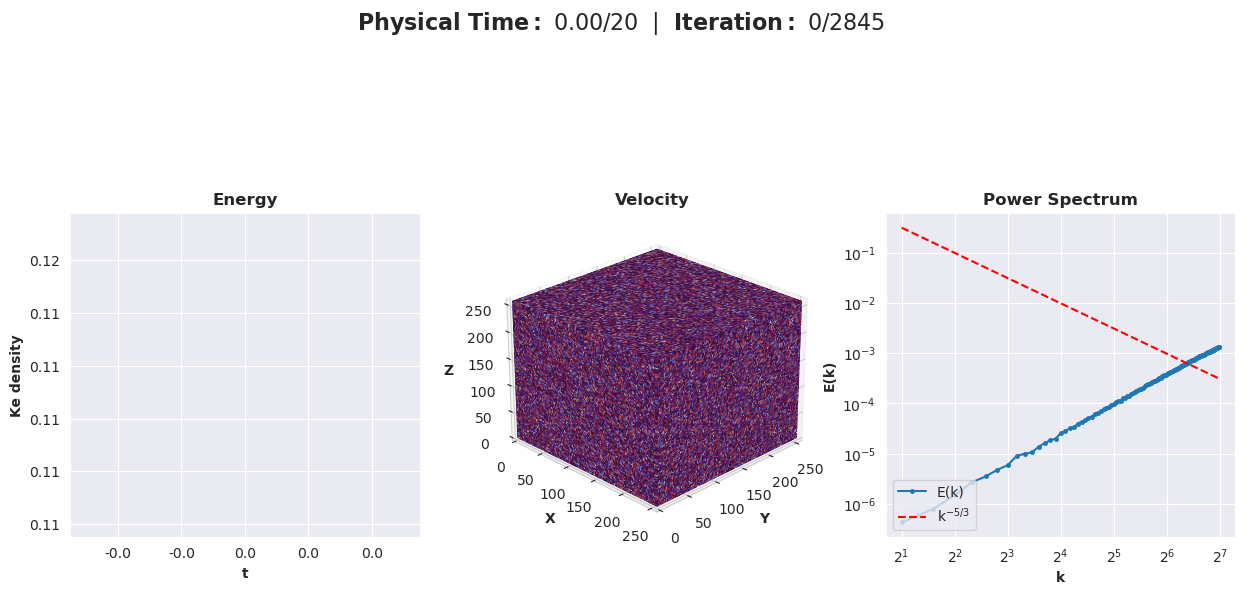

6.894493579864502


  0%|          | 1/2845 [00:08<6:28:52,  8.20s/it]

0.7882421016693115


 10%|█         | 285/2845 [02:22<20:13,  2.11it/s]

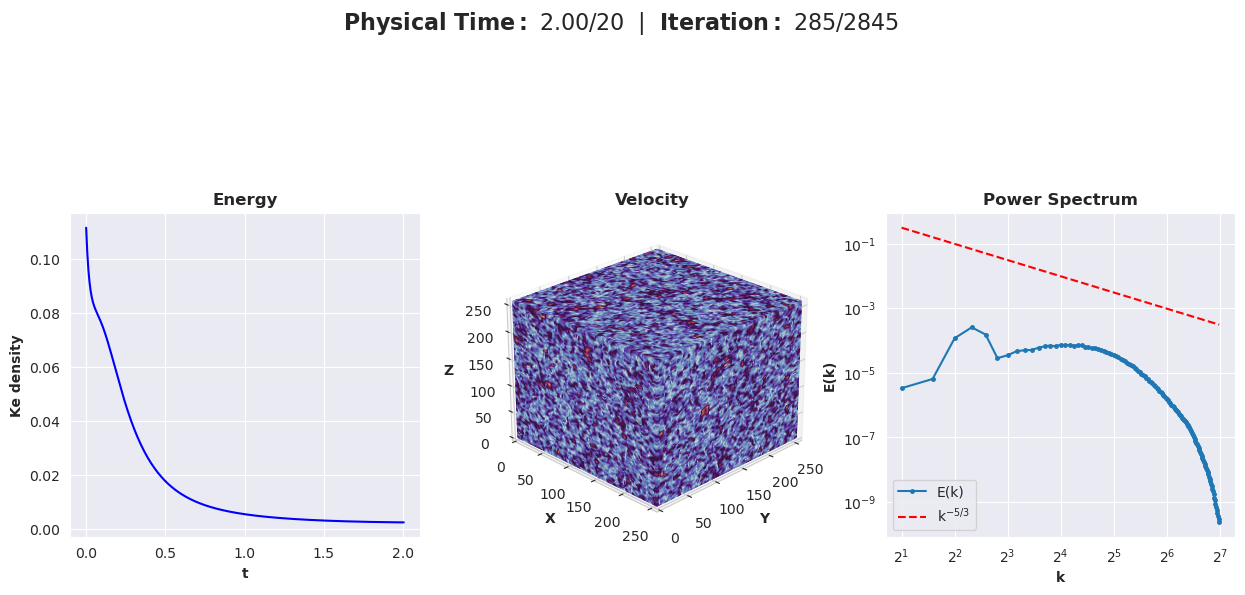

7.5537028312683105


 10%|█         | 286/2845 [02:31<2:00:57,  2.84s/it]

0.779625654220581


 20%|██        | 570/2845 [04:45<17:57,  2.11it/s]  

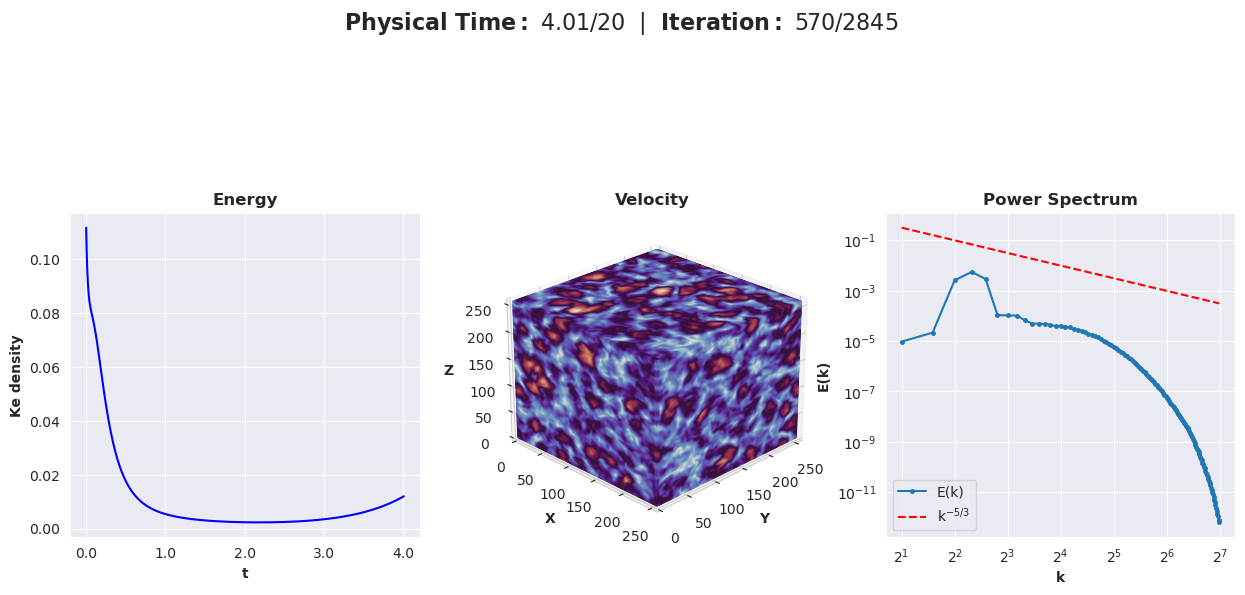

7.501614332199097


 20%|██        | 571/2845 [04:54<1:46:58,  2.82s/it]

0.7872698307037354


 30%|███       | 855/2845 [07:08<15:44,  2.11it/s]  

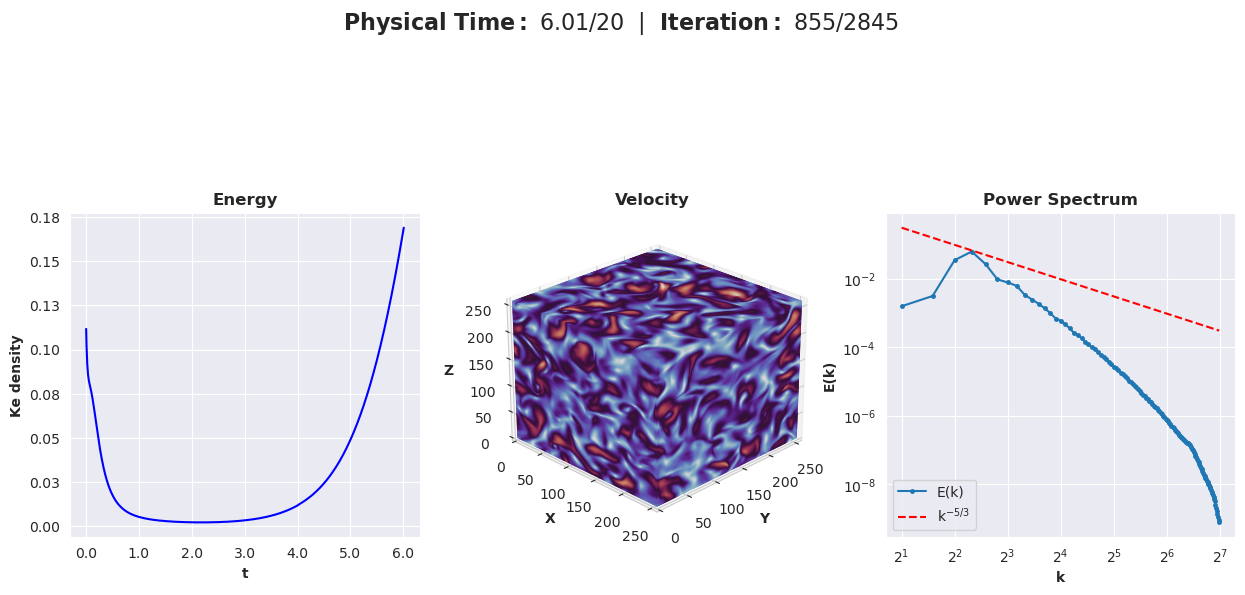

7.374298095703125


 30%|███       | 856/2845 [07:16<1:32:16,  2.78s/it]

0.781109094619751


 40%|████      | 1140/2845 [09:31<13:27,  2.11it/s] 

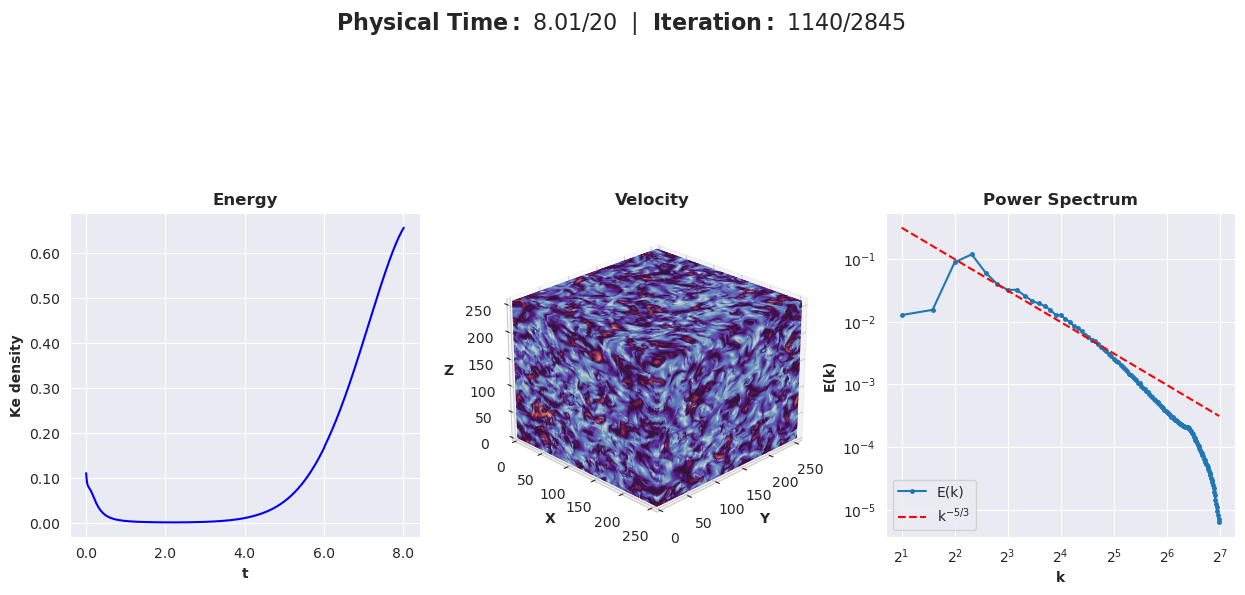

7.54053807258606


 40%|████      | 1141/2845 [09:39<1:20:36,  2.84s/it]

0.8006031513214111


 50%|█████     | 1425/2845 [11:54<11:13,  2.11it/s]  

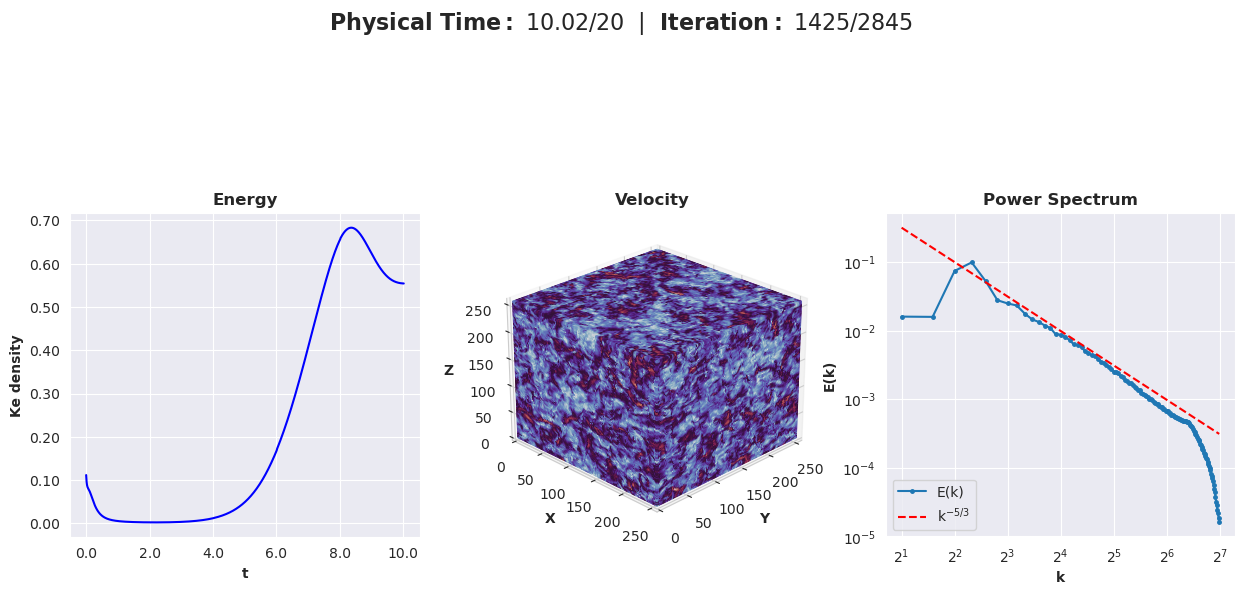

7.748904466629028


 50%|█████     | 1426/2845 [12:03<1:08:30,  2.90s/it]

0.7837135791778564


 60%|██████    | 1710/2845 [14:17<08:57,  2.11it/s]  

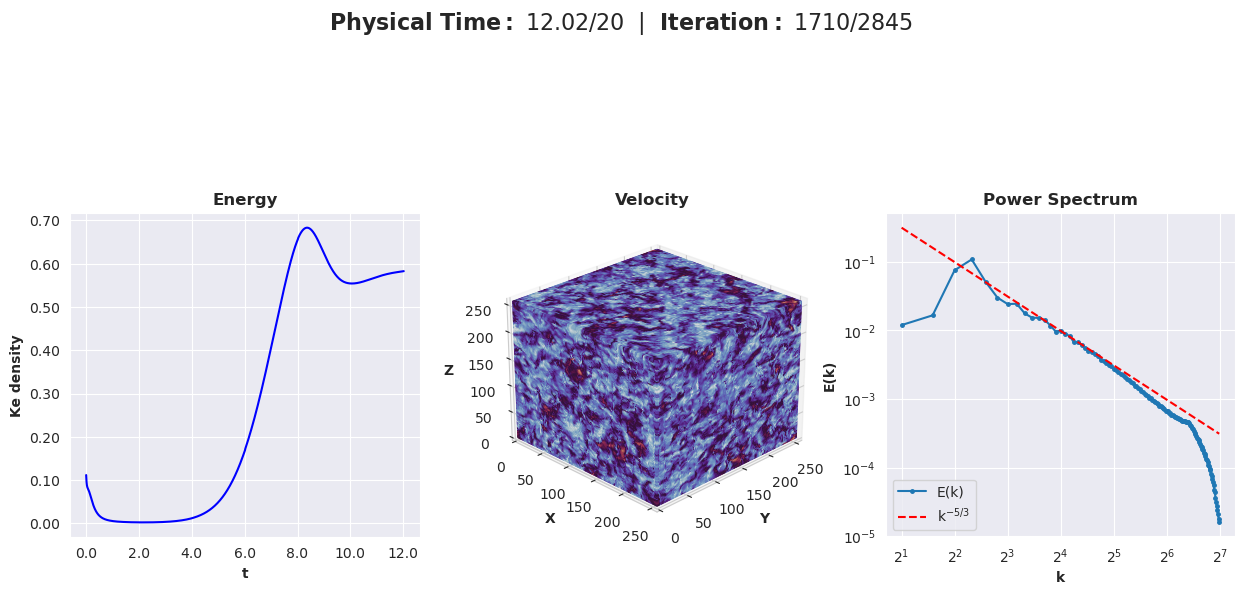

7.544957876205444


 60%|██████    | 1711/2845 [14:25<53:36,  2.84s/it]

0.7904891967773438


 70%|███████   | 1995/2845 [16:40<06:43,  2.11it/s]

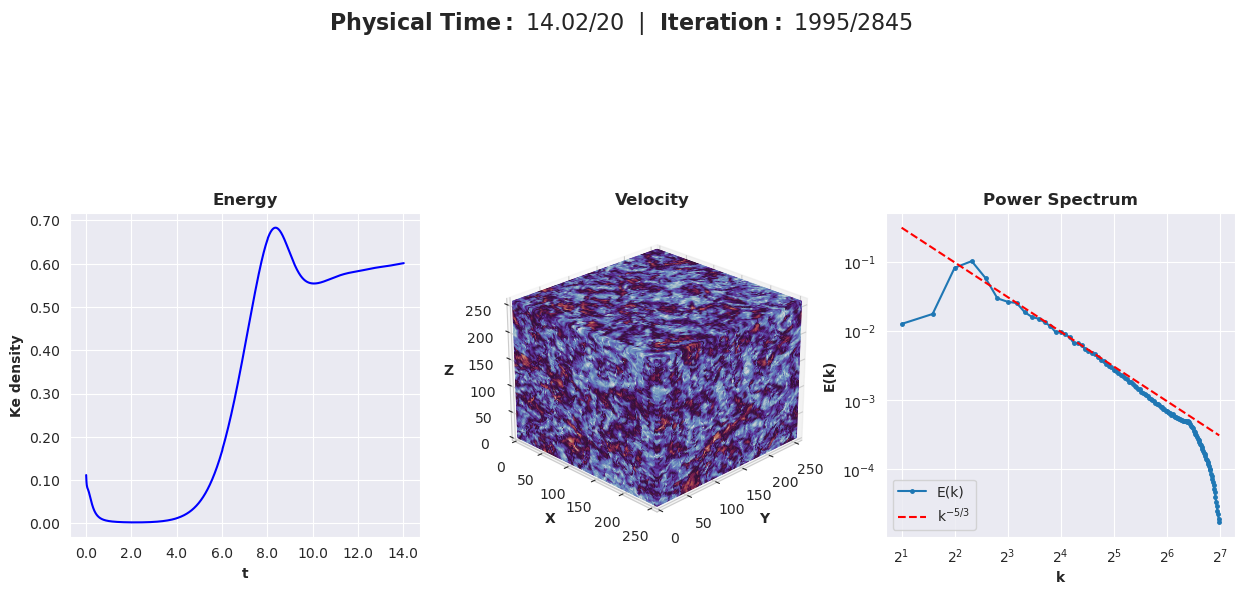

7.428455829620361


 70%|███████   | 1996/2845 [16:48<39:34,  2.80s/it]

0.7740054130554199


 80%|████████  | 2280/2845 [19:03<04:27,  2.11it/s]

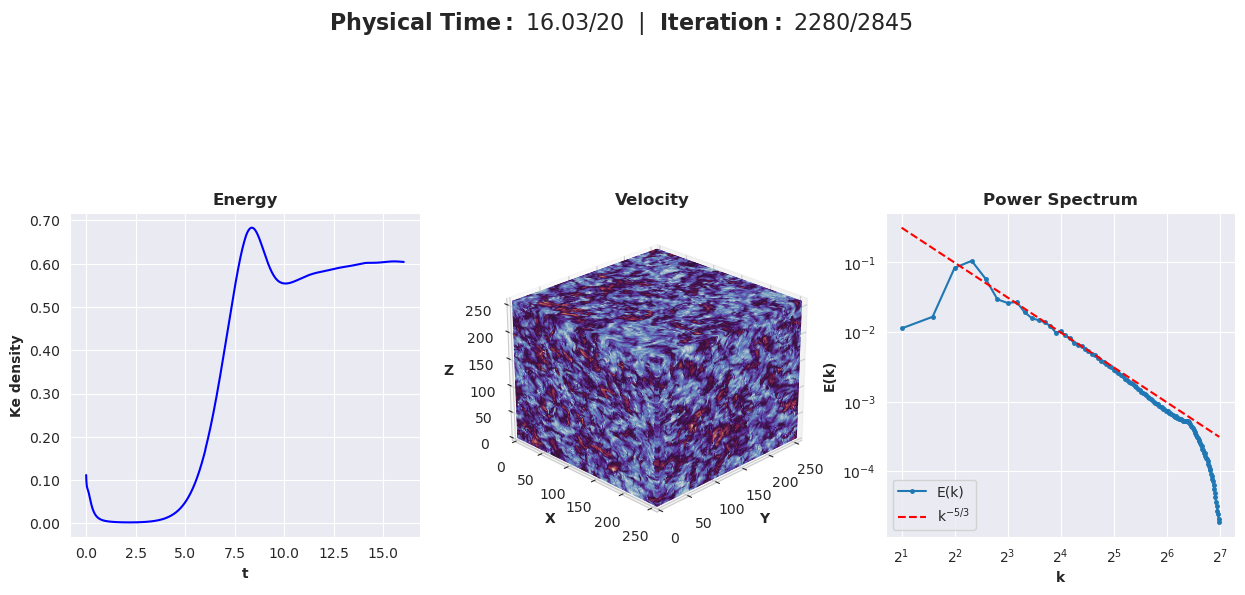

7.541039705276489


 80%|████████  | 2281/2845 [19:11<26:37,  2.83s/it]

0.7789349555969238


 90%|█████████ | 2565/2845 [21:26<02:12,  2.11it/s]

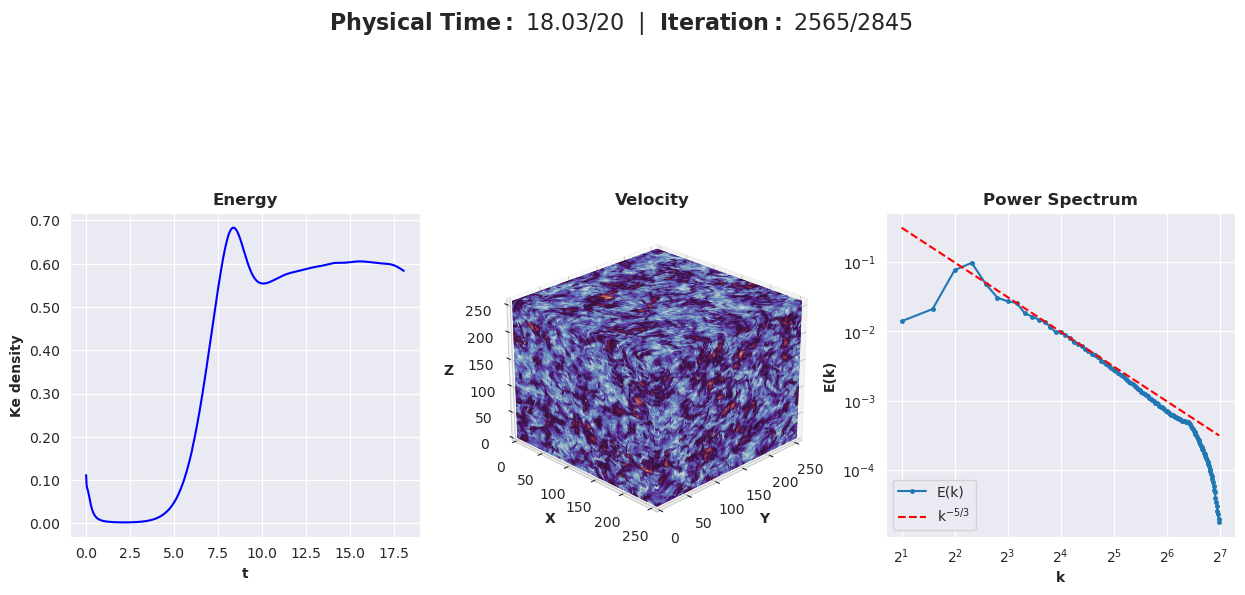

7.557626247406006


 90%|█████████ | 2566/2845 [21:34<13:12,  2.84s/it]

0.7944135665893555


100%|██████████| 2845/2845 [23:47<00:00,  2.11it/s]

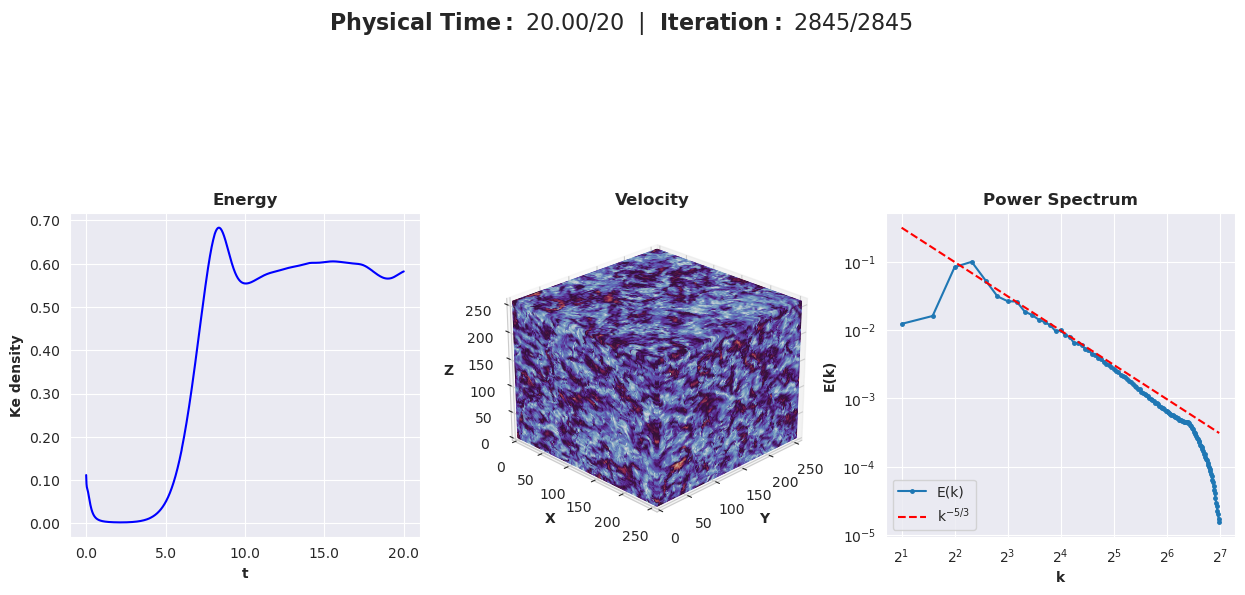

7.158689737319946


2846it [23:55,  1.98it/s]                          

0.68680739402771


In [14]:
def ComputeRHS(dU, rk, forcing_type=None):
    """
    Compute the Navier–Stokes right-hand side for Runge–Kutta integration.

    Includes nonlinear term, projection for incompressibility, viscosity, and dealiasing.

    Args:
        dU (cupy.ndarray): Output buffer for RHS term.
        rk (int): Runge–Kutta sub-stage index.

    Returns:
        cupy.ndarray: Updated RHS term stored in dU.
    """

    global U
    
    if rk > 0:
        
        for i in range(3):
            U[i] = ifftn_serial(U_hat[i], U[i])

    #amp = 0.22 # 0.22
    #U += apply_physical_forcing(U, X, k_f=8, amplitude=amp, forcing_type=forcing_type)
    
    curl[:] = Curl(U_hat, curl)
    dU = Cross(U, curl, dU)
    
    dU *= dealias

    dU += apply_spectral_forcing(U_hat, K, k_f=5, amplitude=0.8, forcing_type=forcing_type)                # Force used: 0.2
    
    P_hat[:] = cp.sum(dU*K_over_K2, 0, out=P_hat)
    dU -= P_hat*K

    dU -= viscosity*K2*U_hat

    return dU

# --- // ---

#List to save plots:
plot_filenames_1 = []
plot_filenames_2 = []

#List to save metrics:
metric_list_1 = []
metric_list_2 = []
metric_list_3 = []
metric_list_4 = []

# SIMULATION PARAMETERS:
viscosity = 1/1800                   # Viscosity = 1/Reynolds. Suggestion: Reynolds -> 1600
t_f = 20 # 68 # 20                   # Final physical time
dt = 0.00703                         # Time step.
N = 2**8                             # Grid dimension
IC_type = 'random_vel'               # Initial conditions. Check initial_conditions.py
forcing_type = 'multiple_wavenumber' # 'fixed_wavenumber'               # Type of forcing (if you dont want it, use None)
n_steps = int(cp.ceil(t_f/dt))       # Number of frames in the simulation
every = int(cp.ceil(n_steps/10))     # Plot and or calculate "every" iterations:

# Constants:
tg_energy_density = (0.5*((2*cp.pi)**3)/4)/(2*cp.pi)**3 # Initial energy density from taylor green vortex case

# Coordinates and wave numbers:
X = cp.mgrid[:N, :N, :N].astype(float)*2*cp.pi/N # 2*pi is the lenght of the physical domain
kx = fftfreq(N, 1./N)
kz = kx[:(N//2+1)].copy()
kz[-1] *= -1

# 3D wavenumber grid
K = cp.array(cp.meshgrid(kx, kx, kz, indexing='ij'), dtype=int)
K2 = cp.sum(K*K, 0, dtype=int)
K_over_K2 = K.astype(float) / cp.where(K2 == 0, 1, K2).astype(float)

# Define dealias:
kmax_dealias = 2./3.*(N//2+1)
dealias = cp.array((abs(K[0]) < kmax_dealias)*
                   (abs(K[1]) < kmax_dealias)*
                   (abs(K[2]) < kmax_dealias), dtype=bool)

# Preallocate arrays
U = cp.empty((3, N, N, N))
U_hat = cp.empty((3, N, N, N//2+1), dtype=complex)
P = cp.empty((N, N, N))
P_hat = cp.empty((N, N, N//2+1), dtype=complex)
U_hat0 = cp.empty((3, N, N, N//2+1), dtype=complex)
U_hat1 = cp.empty((3, N, N, N//2+1), dtype=complex)
dU = cp.empty((3, N, N, N//2+1), dtype=complex)
Uc_hat = cp.empty((N, N, N//2+1), dtype=complex)
Uc_hatT = cp.empty((N, N, N//2+1), dtype=complex)
curl = cp.empty((3, N, N, N))

# Runge-Kutta coefficients:
a = [1./6., 1./3., 1./3., 1./6.]
b = [0.5, 0.5, 1.]

# --- MAIN LOOP: ---
pbar = tqdm(total=int(n_steps))

# Initial velocity initial field (in physical and spectral space):
U, U_hat = IC_3D(X, IC_type)

# Plot the initial state of the simulation (Obs.: only the velocity was initiated):
# plot(cp.ones_like(P), U, cp.ones_like(curl), float('NaN'), t_f, float('NaN'), n_steps)
# plot_pvv(cp.ones_like(P), U, cp.ones_like(curl), float('NaN'), t_f, float('NaN'), n_steps)
# plot_uvw(U, float('NaN'), t_f, float('NaN'), n_steps)

for n in range(n_steps + 1):

    # If you need to generate random wave numbers to force:
    # if n == 0:  # First iteration, just generate a random number
    #     k_f_random = cp.random.randint(4, 7)
    # else:  # Subsequent iterations, ensure it's different from the last number
    #     new_random = cp.random.randint(4, 7)
    #     while new_random == k_f_random:  # Check against the previous number
    #         new_random = cp.random.randint(4, 7)
    #     k_f_random = new_random  # Update the previous number
    
    #Initialize U_hat1 and U_hat0 (copies of U_hat used on intermediate steps of Runge-Kutta)
    U_hat1[:] = U_hat0[:] = U_hat

    #Runge-Kutta integration
    for rk in range(4):
        dU = ComputeRHS(dU, rk, forcing_type)                #Compute the right-hand side of N-S equations
        if rk < 3:
            U_hat[:] = U_hat0 + b[rk]*dt*dU    # Update U_hat based on R-K coefficients b
        U_hat1[:] += a[rk]*dt*dU               # Update U_hat1 based on R-K coefficients a

    U_hat[:] = U_hat1[:]                       # Update U-hat with the final results on U_hat1
    
    
    
    # Compute metrics:
    if n%every or n==0 or n==n_steps: #int(cp.ceil(n_steps/50)) or n%every==0 or n==0 or n==n_steps
    
        # Power spectrum:
        wave_numbers, tke_spectrum = tke_spectrum_physical_space(U, 2*cp.pi, False)
        #wave_numbers, tke_spectrum = tke_spectrum_spectral_space(U_hat, 2*cp.pi, False)
        
        # Kinetic energy:
        # metric_list_1.append(energy_physical_space(U, N).item())
        # metric_list_1.append((0.5 * cp.sum(cp.abs(U)**2)*(1/N)**3).item())
        metric_list_1.append(np.sum(tke_spectrum).item())
    
        metric_list_2.append(wave_numbers)
        metric_list_3.append(tke_spectrum)
        metric_list_4.append(n)

        # Enstrophy:
        # metric_list_2.append(enstrophy_physical_space(curl, N).item())

        # Structure Function:
        '''
        start_time = time.time()
        structure_function, structure_function_x, structure_function_y, structure_function_z = structure_function_physical_space(U, lags=cp.linspace(1, N//2, 15, dtype=int).tolist(), export_components=True)
        print('time:', time.time()-start_time)
        
        print(list(structure_function.keys()))
        print(list(structure_function.values()))

        plt.loglog(list(structure_function.keys()), list(structure_function.values()), marker='.')
        plt.loglog(list(structure_function.keys()), [1**(2/3) * x**(2/3)/10 for x in list(structure_function.keys())], marker='.')
        plt.show()

        plt.semilogx(list(structure_function.keys()), list(structure_function.values()), base=2, markersize=2.5, marker='o', label=r'$S(l)$')
        plt.semilogy(list(structure_function.keys()), [x**(2/3)/10 for x in list(structure_function.keys())], 'r--', label=r'$\mathrm{l^{2/3}10^{-1}$')        
        plt.show()
        '''

    
    # Plot/Save at intervals
    if n%every==0 or n==0 or n==n_steps: # n%int(cp.ceil(n_steps/150))==0 #Suggestion: plot every 150 iterations to animate
        
        start_time = time.time()
        
        # clear_output(wait=True)
        
        # plot_pressure_curl_velocity(ifftn_serial(P_hat, P), U, curl, n*dt, t_f, n, n_steps, plot_type='external_faces_1', stride=3, show_plot=True, save_plot=False, colormap='coolwarm')
        # plot_pressure_curl_velocity(ifftn_serial(P_hat, P), U, curl, n*dt, t_f, n, n_steps, plot_type='external_faces_1', stride=1, show_plot=True, save_plot=False, colormap='twilight') #, colormap='Spectral'
        # plot_energy_velocity_enstrophy(U, metric_list_1, metric_list_2, n*dt, t_f, n, n_steps, 'external_faces_1', stride=1, show_plot=True, save_plot=False)
        plot_energy_velocity_spectrum(U, wave_numbers, tke_spectrum, metric_list_1, n*dt, t_f, n, n_steps, 'external_faces_1', stride=2, show_plot=True, save_plot=False)

        print(time.time()-start_time)
    
    if n%every==0 or n==0 or n==n_steps: #Suggestion: plot every 150 iterations to animate
        
        start_time = time.time()
        
        folder_path = '/kaggle/working/'
        
        file_name_1 = 'curl_n_'+str(n)+'.npy'
        plot_filenames_1.append(folder_path+file_name_1)                           
        cp.save(folder_path+file_name_1, curl)
        
        file_name_2 = 'U_'+str(n)+'.npy'
        plot_filenames_2.append(folder_path+file_name_2)
        cp.save(folder_path+file_name_2, U)
    
        print(time.time()-start_time)
    
    pbar.update(1)
    
pbar.close()

# Convert and save all at once
metrics_data = {
    'metric_1': np.array([cp.asnumpy(x) if isinstance(x, cp.ndarray) else x for x in metric_list_1]),
    'metric_2': np.array([cp.asnumpy(x) if isinstance(x, cp.ndarray) else x for x in metric_list_2]),
    'metric_3': np.array([cp.asnumpy(x) if isinstance(x, cp.ndarray) else x for x in metric_list_3]),
    'metric_4': np.array([cp.asnumpy(x) if isinstance(x, cp.ndarray) else x for x in metric_list_4])
}

np.savez('metrics_combined.npz', **metrics_data)


# Create an animation:

In [ ]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

In [16]:
!pip install imageio==2.19.3
!pip install imageio-ffmpeg==0.4.7
# import imageio
import imageio.v2 as imageio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 34.9 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: imageio
    Found existing installation: imageio 2.31.1
    Uninstalling imageio-2.31.1:
      Successfully uninstalled imageio-2.31.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-image 0.21.0 requires imageio>=2.27, but you have imageio 2.19.3 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.9/26.9 MB 53.6 MB/s eta 0:00:0000:0100:01


In [22]:
plot_filenames

['plot_plot_energy_curl_spectrum_0.png',
 'plot_plot_energy_curl_spectrum_84.png',
 'plot_plot_energy_curl_spectrum_168.png',
 'plot_plot_energy_curl_spectrum_252.png',
 'plot_plot_energy_curl_spectrum_336.png',
 'plot_plot_energy_curl_spectrum_420.png',
 'plot_plot_energy_curl_spectrum_504.png',
 'plot_plot_energy_curl_spectrum_588.png',
 'plot_plot_energy_curl_spectrum_672.png',
 'plot_plot_energy_curl_spectrum_756.png',
 'plot_plot_energy_curl_spectrum_840.png',
 'plot_plot_energy_curl_spectrum_924.png',
 'plot_plot_energy_curl_spectrum_1008.png',
 'plot_plot_energy_curl_spectrum_1092.png',
 'plot_plot_energy_curl_spectrum_1176.png',
 'plot_plot_energy_curl_spectrum_1260.png',
 'plot_plot_energy_curl_spectrum_1344.png',
 'plot_plot_energy_curl_spectrum_1428.png',
 'plot_plot_energy_curl_spectrum_1512.png',
 'plot_plot_energy_curl_spectrum_1596.png',
 'plot_plot_energy_curl_spectrum_1680.png',
 'plot_plot_energy_curl_spectrum_1764.png',
 'plot_plot_energy_curl_spectrum_1848.png',
 'p

In [23]:
fps = 10  # Desired FPS
duration = 1 / fps  # Calculate duration for each frame

with imageio.get_writer('/kaggle/working/animation.mp4', mode='I', fps=fps) as writer: # Kaggle: '/kaggle/working/animation.mp4' or on Colab: 'animation.mp4'
    for filename in plot_filenames:
        image = imageio.imread(filename)
        writer.append_data(image)


In [ ]:
fps = 20  # Desired FPS
duration = 1 / fps  # Calculate duration for each frame

with imageio.get_writer('/content/drive/MyDrive/animation.gif', mode='I', duration=duration) as writer:
    for filename in plot_filenames:
        image = imageio.imread(filename)
        writer.append_data(image)


# Delete stored files:

In [10]:
import os
import shutil

# List all files in /kaggle/working
folder = '/kaggle/working'
for filename in os.listdir(folder):
    file_path = os.path.join(folder, filename)
    try:
        if os.path.isfile(file_path) or os.path.islink(file_path):
            os.unlink(file_path)  # Remove the file
        elif os.path.isdir(file_path):
            shutil.rmtree(file_path)  # Remove the folder
    except Exception as e:
        print(f'Failed to delete {file_path}. Reason: {e}')
